In [ ]:
# Установка необходимых библиотек (выполняется один раз в Colab)
#!pip install scipy matplotlib numpy requests

import os
import zipfile
import requests
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import warnings
warnings.filterwarnings('ignore')

# ==================== 1. ЗАГРУЗКА ДАТАСЕТА ====================
from google.colab import drive
drive.mount('/content/drive')

# Базовый путь к данным
base_data_path = "/content/drive/MyDrive/EyeMovement_Data/data used in the article"

# Простой способ найти данные
import os
from google.colab import drive

drive.mount('/content/drive')

# Автоматически ищем папку с данными
search_path = '/content/drive/MyDrive'

# Ищем папку содержащую 'data used in the article'
for root, dirs, files in os.walk(search_path):
    if 'data used in the article' in dirs:
        base_data_path = os.path.join(root, 'data used in the article')
        print(f"✅ Найдена папка с данными: {base_data_path}")
        break
else:
    # Если не нашли, показываем структуру
    print("Папка не найдена автоматически. Структура диска:")
    !find "/content/drive/MyDrive" -maxdepth 2 -type d | sort
    base_data_path = input("\n📝 Введите полный путь к папке 'data used in the article': ")

print(f"\nИспользуемый путь: {base_data_path}")

# Проверяем есть ли файлы
if os.path.exists(base_data_path):
    print("\n📁 Содержимое папки:")
    !ls "$base_data_path"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Найдена папка с данными: /content/drive/MyDrive/data used in the article

Используемый путь: /content/drive/MyDrive/data used in the article

📁 Содержимое папки:
dots  img  readme.md  video


In [ ]:
# ==================== 2. ФУНКЦИЯ ДЛЯ АНАЛИЗА ФАЙЛА (АВТОМАТИЧЕСКАЯ) ====================
def analyze_mat_file_auto(file_path):
    """
    Автоматически анализирует .mat файл, определяя категорию и аннотатора из пути.
    Просто укажите полный путь к файлу.
    """
    try:
        # Проверяем существует ли файл
        if not os.path.exists(file_path):
            print(f"❌ Файл не найден: {file_path}")
            return None

        # Определяем имя файла и извлекаем информацию из него
        filename = os.path.basename(file_path)

        # 1. Определяем категорию из структуры пути
        category = "unknown"
        path_parts = file_path.split(os.sep)

        # Ищем известные категории в пути
        known_categories = ['dots', 'img', 'video']
        for cat in known_categories:
            if cat in path_parts:
                category = cat
                break

        # 2. Определяем аннотатора из имени файла
        annotator = "unknown"
        if '_MN.' in filename:
            annotator = 'MN'
        elif '_RA.' in filename:
            annotator = 'RA'

        print(f"📄 Анализ файла: {filename}")
        print(f"   Категория: {category} (автоопределено)")
        print(f"   Аннотатор: {annotator} (автоопределено)")

        # Загружаем файл, упрощая структуры ячеек для удобства
        mat_data = loadmat(file_path, simplify_cells=True)

        # Извлекаем структуру ETdata
        et_data = mat_data['ETdata']

        # Основная матрица данных: [время, диаметр зрачка X, Y, координата X, Y, МЕТКА]
        pos_matrix = et_data['pos']  # Это и есть n x 5 или n x 6 матрица

        # Проверяем, размечен ли файл (есть ли 6-й столбец)
        is_labelled = pos_matrix.shape[1] >= 6
        labels = pos_matrix[:, 5] if is_labelled else None

        # Извлекаем параметры
        samp_freq = et_data['sampFreq']  # Частота дискретизации (Гц)
        screen_res = et_data['screenRes']  # Разрешение экрана [width, height]

        # Рассчитываем длительность записи
        duration_sec = pos_matrix.shape[0] / samp_freq

        # Статистика по меткам (если они есть)
        label_stats = {}
        if is_labelled and labels is not None:
            unique_labels, counts = np.unique(labels, return_counts=True)
            label_stats = dict(zip(unique_labels.astype(int), counts))

            # Преобразуем в обычные int для удобства отображения
            label_stats = {int(k): int(v) for k, v in label_stats.items()}

        # Возвращаем структурированную информацию
        file_info = {
            'full_path': file_path,
            'category': category,
            'annotator': annotator,
            'filename': filename,
            'samples': pos_matrix.shape[0],
            'duration_sec': duration_sec,
            'sampling_freq': samp_freq,
            'screen_res': screen_res.tolist() if isinstance(screen_res, np.ndarray) else screen_res,
            'is_labelled': is_labelled,
            'label_stats': label_stats,
            'data': pos_matrix,  # Вся матрица данных
            'gaze_x': pos_matrix[:, 3],  # X координата взгляда (столбец 4)
            'gaze_y': pos_matrix[:, 4],  # Y координата взгляда (столбец 5)
            'labels': labels  # Метки (столбец 6, если есть)
        }

        # Выводим краткую информацию
        print(f"   ✅ Успешно загружено")
        print(f"   Сэмплов: {file_info['samples']:,}")
        print(f"   Длительность: {file_info['duration_sec']:.2f} сек")
        print(f"   Частота: {file_info['sampling_freq']} Гц")

        if is_labelled:
            print(f"   Размечен: ДА")
            if label_stats:
                print(f"   Распределение меток: {label_stats}")
        else:
            print(f"   Размечен: НЕТ")

        return file_info

    except Exception as e:
        print(f"❌ Ошибка при загрузке {file_path}: {e}")
        import traceback
        traceback.print_exc()
        return None

# ==================== ФУНКЦИИ ВИЗУАЛИЗАЦИИ ====================

def plot_time_series_simple(file_info):
    """
    Простая временная диаграмма координат X и Y
    """
    if file_info is None:
        print("❌ Нет данных для визуализации")
        return

    print(f"📈 График 1: Временные ряды координат")

    time_seconds = np.arange(file_info['samples']) / file_info['sampling_freq']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

    # X координата
    ax1.plot(time_seconds, file_info['gaze_x'], 'b-', linewidth=0.5, alpha=0.7)
    ax1.set_ylabel('X координата (пиксели)')
    ax1.set_title(f"Временной ряд координат: {file_info['filename']}")
    ax1.grid(True, alpha=0.3)

    # Y координата
    ax2.plot(time_seconds, file_info['gaze_y'], 'g-', linewidth=0.5, alpha=0.7)
    ax2.set_ylabel('Y координата (пиксели)')
    ax2.set_xlabel('Время (секунды)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_labels_distribution_simple(file_info):
    """
    Простая гистограмма распределения меток
    """
    if file_info is None or not file_info['is_labelled']:
        print("❌ Файл не размечен или нет данных")
        return

    print(f"📊 График 2: Распределение меток")

    labels = file_info['labels']
    unique_labels = np.unique(labels)

    # Названия меток
    label_names = {
        1: 'Фиксация', 2: 'Саккада', 3: 'PSO',
        4: 'Плавное слеж.', 5: 'Моргание', 6: 'Неопр.'
    }

    colors = ['red', 'green', 'yellow', 'pink', 'black', 'cyan']

    fig, ax = plt.subplots(figsize=(10, 5))

    # Считаем количество каждой метки
    counts = [np.sum(labels == label) for label in unique_labels]
    label_texts = [label_names.get(int(label), f'Метка {int(label)}') for label in unique_labels]

    # Цвета для каждого столбца
    bar_colors = [colors[int(label)-1] if 1 <= int(label) <= 6 else 'gray'
                  for label in unique_labels]

    bars = ax.bar(label_texts, counts, color=bar_colors, alpha=0.7)

    # Подписи сверху столбцов
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({count/len(labels)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)

    ax.set_ylabel('Количество сэмплов')
    ax.set_title(f"Распределение меток: {file_info['filename']}")
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

def plot_2d_trajectory_simple(file_info):
    """
    Простая 2D траектория взгляда
    """
    if file_info is None:
        print("❌ Нет данных для визуализации")
        return

    print(f"📍 График 3: 2D траектория взгляда")

    fig, ax = plt.subplots(figsize=(10, 8))

    if file_info['is_labelled'] and file_info['labels'] is not None:
        # Если есть метки, рисуем цветными точками
        labels = file_info['labels']
        unique_labels = np.unique(labels)

        color_map = {1: 'red', 2: 'green', 3: 'yellow',
                    4: 'pink', 5: 'black', 6: 'cyan'}

        for label in unique_labels:
            mask = labels == label
            if np.any(mask):
                ax.scatter(file_info['gaze_x'][mask], file_info['gaze_y'][mask],
                          c=color_map.get(label, 'gray'), s=1, alpha=0.6,
                          label=f'Метка {int(label)}')

        ax.legend(markerscale=5, fontsize=9)
    else:
        # Если нет меток, просто линия
        ax.plot(file_info['gaze_x'], file_info['gaze_y'],
                'b-', alpha=0.5, linewidth=0.5)

    # Настройки осей
    screen_w, screen_h = file_info['screen_res'][0], file_info['screen_res'][1]
    ax.set_xlim(0, screen_w)
    ax.set_ylim(screen_h, 0)  # Инвертируем Y (как в изображениях)
    ax.set_xlabel('X координата (пиксели)')
    ax.set_ylabel('Y координата (пиксели)')
    ax.set_title(f"2D траектория взгляда: {file_info['filename']}")
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

def plot_labels_over_time_simple(file_info):
    """
    Простая временная шкала с цветными метками
    """
    if file_info is None or not file_info['is_labelled']:
        print("❌ Файл не размечен или нет данных")
        return

    print(f"🕒 График 4: Временная шкала меток")

    time_seconds = np.arange(file_info['samples']) / file_info['sampling_freq']
    labels = file_info['labels']

    color_map = {1: 'red', 2: 'green', 3: 'yellow',
                 4: 'pink', 5: 'black', 6: 'cyan'}
    label_names = {1: 'Фиксация', 2: 'Саккада', 3: 'PSO',
                   4: 'Плавное слеж.', 5: 'Моргание', 6: 'Неопр.'}

    fig, ax = plt.subplots(figsize=(12, 3))

    # Находим границы между разными метками
    changes = np.diff(labels, prepend=labels[0]-1)
    change_points = np.where(changes != 0)[0]

    # Рисуем цветные полосы
    for i in range(len(change_points)):
        start_idx = change_points[i]
        end_idx = change_points[i+1] if i+1 < len(change_points) else len(labels)
        label = int(labels[start_idx])

        ax.axvspan(time_seconds[start_idx], time_seconds[end_idx-1],
                  alpha=0.5, color=color_map.get(label, 'gray'),
                  label=label_names.get(label, f'Метка {label}') if i == 0 else "")

    ax.set_xlabel('Время (секунды)')
    ax.set_ylabel('События')
    ax.set_yticks([])
    ax.set_xlim(time_seconds[0], time_seconds[-1])
    ax.set_title(f"Временная шкала событий: {file_info['filename']}")

    # Убираем дубли в легенде
    handles, labels_leg = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_leg, handles))
    if by_label:
        ax.legend(by_label.values(), by_label.keys(), loc='upper right')

    plt.tight_layout()
    plt.show()

def plot_velocity_profile_simple(file_info):
    """
    Простой график скорости движения глаз
    (важно для различения саккад и фиксаций)
    """
    if file_info is None:
        print("❌ Нет данных для визуализации")
        return

    print(f"⚡ График 5: Профиль скорости")

    time_seconds = np.arange(file_info['samples']) / file_info['sampling_freq']

    # Вычисляем скорость
    dt = 1.0 / file_info['sampling_freq']
    velocity_x = np.abs(np.gradient(file_info['gaze_x'], dt))
    velocity_y = np.abs(np.gradient(file_info['gaze_y'], dt))
    speed = np.sqrt(velocity_x**2 + velocity_y**2)

    fig, ax = plt.subplots(figsize=(12, 4))

    # Рисуем скорость
    ax.plot(time_seconds, speed, 'r-', linewidth=0.7, alpha=0.8, label='Скорость')

    # Порог для саккад (примерно 30 пикс/сек на 500 Гц)
    saccade_threshold = 30
    ax.axhline(y=saccade_threshold, color='green', linestyle='--',
               alpha=0.5, label=f'Порог саккад ({saccade_threshold} пикс/сек)')

    # Если есть метки, подсвечиваем саккады
    if file_info['is_labelled'] and file_info['labels'] is not None:
        saccade_mask = file_info['labels'] == 2
        if np.any(saccade_mask):
            ax.fill_between(time_seconds, 0, np.max(speed)*1.1,
                           where=saccade_mask, color='green', alpha=0.2,
                           label='Саккады (по меткам)')

    ax.set_xlabel('Время (секунды)')
    ax.set_ylabel('Скорость (пиксели/секунду)')
    ax.set_title(f"Профиль скорости: {file_info['filename']}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

def visualize_all_simple(file_info):
    """
    Вызывает все графики последовательно
    """
    print(f"\n{'='*60}")
    print(f"🎨 ПОЛНАЯ ВИЗУАЛИЗАЦИЯ ФАЙЛА: {file_info['filename'] if file_info else 'N/A'}")
    print('='*60)

    if file_info is None:
        print("❌ Нет данных для визуализации")
        return

    # 1. Временные ряды
    plot_time_series_simple(file_info)

    # 2. Распределение меток (если есть)
    if file_info['is_labelled']:
        plot_labels_distribution_simple(file_info)

    # 3. 2D траектория
    plot_2d_trajectory_simple(file_info)

    # 4. Временная шкала (если есть метки)
    if file_info['is_labelled']:
        plot_labels_over_time_simple(file_info)

    # 5. Профиль скорости
    plot_velocity_profile_simple(file_info)

    print(f"\n✅ Визуализация завершена!")

📄 Анализ файла: TH34_img_Europe_labelled_MN.mat
   Категория: img (автоопределено)
   Аннотатор: MN (автоопределено)
   ✅ Успешно загружено
   Сэмплов: 4,988
   Длительность: 9.98 сек
   Частота: 500 Гц
   Размечен: ДА
   Распределение меток: {1: 4282, 2: 503, 3: 203}

🎨 ПОЛНАЯ ВИЗУАЛИЗАЦИЯ ФАЙЛА: TH34_img_Europe_labelled_MN.mat
📈 График 1: Временные ряды координат


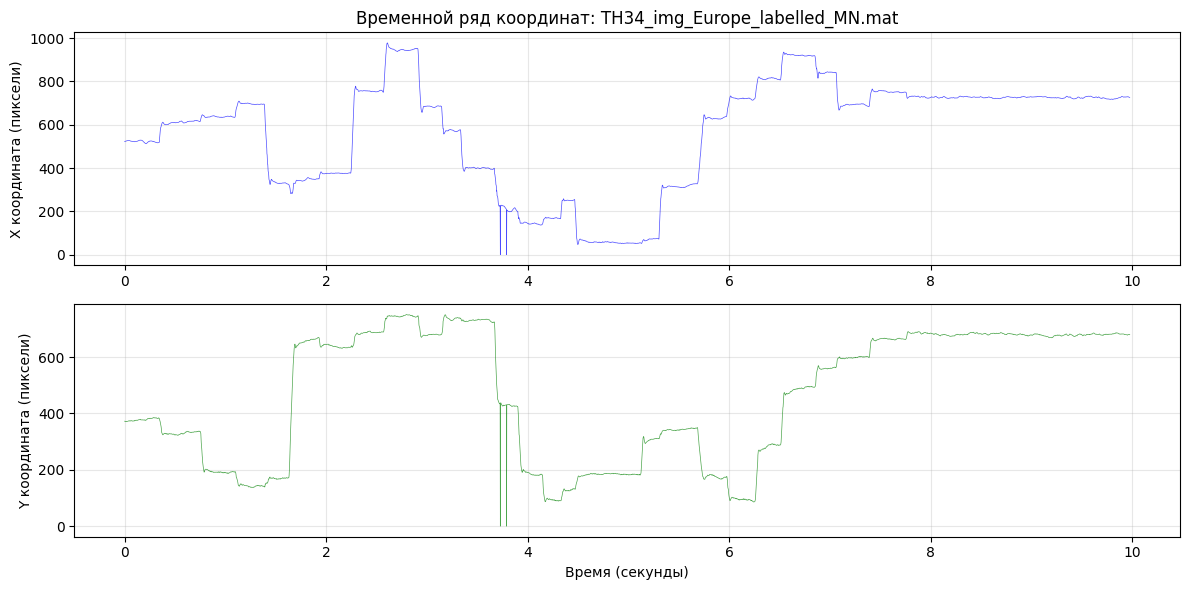

📊 График 2: Распределение меток


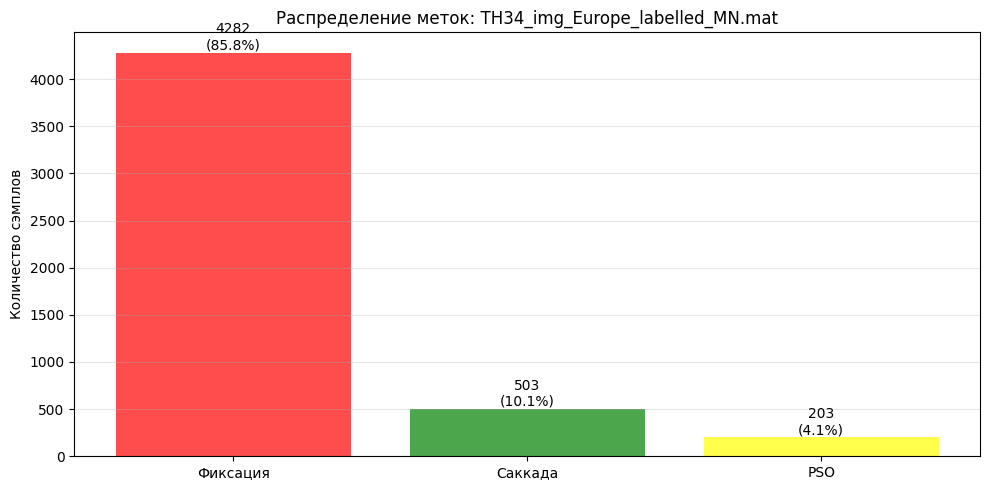

📍 График 3: 2D траектория взгляда


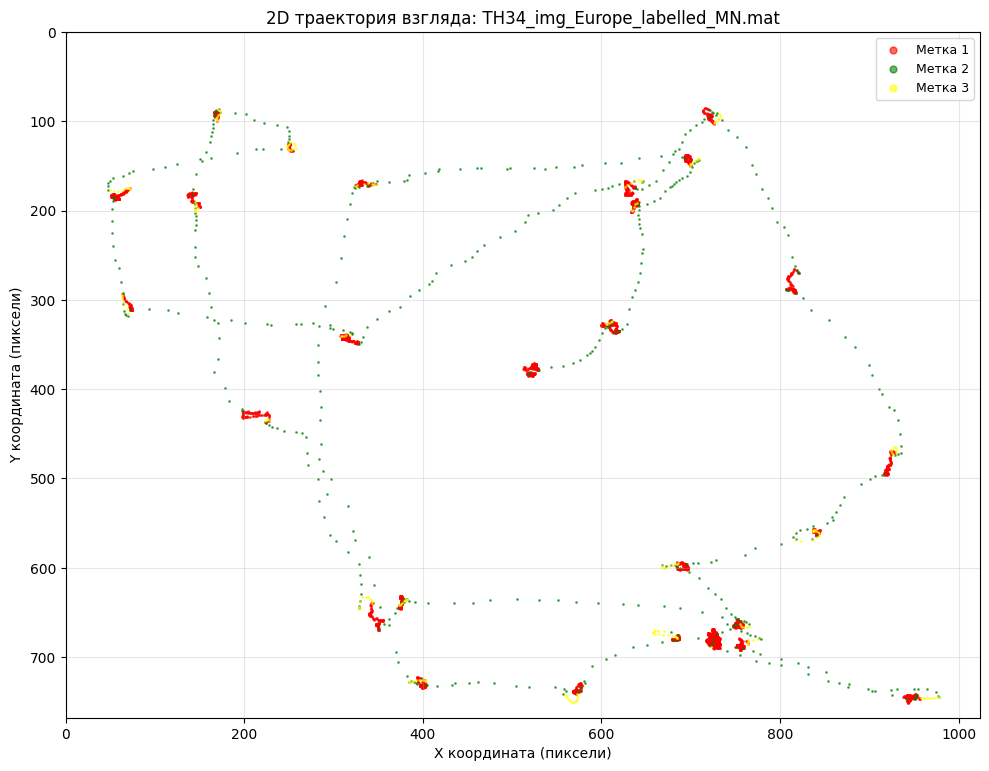

🕒 График 4: Временная шкала меток


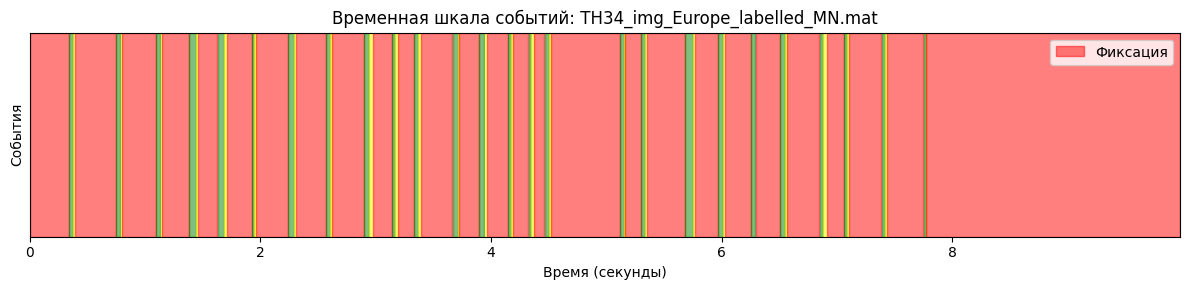

⚡ График 5: Профиль скорости


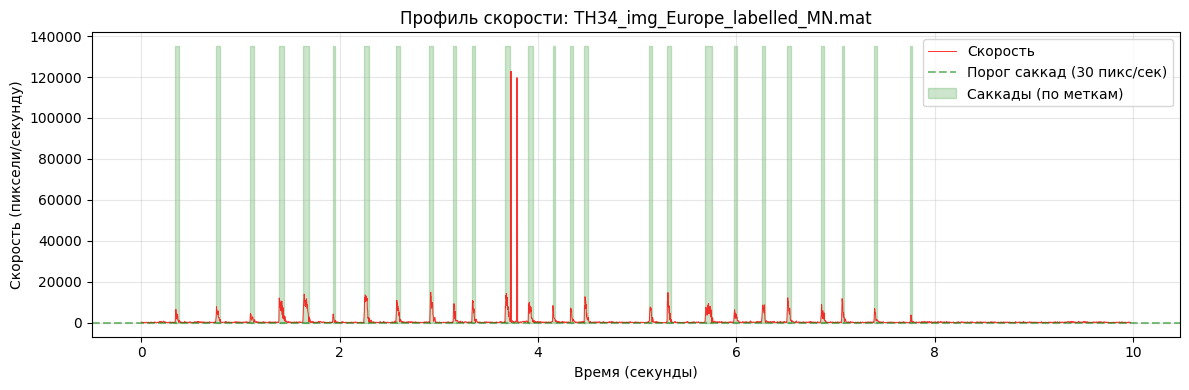


✅ Визуализация завершена!


In [ ]:
# 1. Проанализировать файл
file_path = "/content/drive/MyDrive/data used in the article/img/TH34_img_Europe_labelled_MN.mat"
file_info = analyze_mat_file_auto(file_path)

# 2. Визуализировать все графики
if file_info:
    visualize_all_simple(file_info)

# ИЛИ вызывать графики по отдельности:
# plot_time_series_simple(file_info)        # Только временные ряды
# plot_labels_distribution_simple(file_info) # Только гистограмма меток
# plot_2d_trajectory_simple(file_info)      # Только 2D траектория

In [ ]:
# ==================== 2. ФУНКЦИЯ ДЛЯ АНАЛИЗА ФАЙЛА ====================
def analyze_mat_file(file_path, category, annotator):
    """
    Загружает и анализирует один .mat файл.
    Возвращает основные данные и статистику.
    """
    try:
        # Загружаем файл, упрощая структуры ячеек для удобства
        mat_data = loadmat(file_path, simplify_cells=True)

        # Извлекаем структуру ETdata
        et_data = mat_data['ETdata']

        # Основная матрица данных: [время, диаметр зрачка X, Y, координата X, Y, МЕТКА]
        pos_matrix = et_data['pos']  # Это и есть n x 5 или n x 6 матрица

        # Проверяем, размечен ли файл (есть ли 6-й столбец)
        is_labelled = pos_matrix.shape[1] >= 6
        labels = pos_matrix[:, 5] if is_labelled else None

        # Извлекаем параметры
        samp_freq = et_data['sampFreq']  # Частота дискретизации (Гц)
        screen_res = et_data['screenRes']  # Разрешение экрана [width, height]

        # Рассчитываем длительность записи
        duration_sec = pos_matrix.shape[0] / samp_freq

        # Статистика по меткам (если они есть)
        label_stats = {}
        if is_labelled and labels is not None:
            unique_labels, counts = np.unique(labels, return_counts=True)
            label_stats = dict(zip(unique_labels.astype(int), counts))

        # Возвращаем структурированную информацию
        file_info = {
            'category': category,
            'annotator': annotator,
            'filename': os.path.basename(file_path),
            'samples': pos_matrix.shape[0],
            'duration_sec': duration_sec,
            'sampling_freq': samp_freq,
            'screen_res': screen_res,
            'is_labelled': is_labelled,
            'label_stats': label_stats,
            'data': pos_matrix,  # Вся матрица данных
            'gaze_x': pos_matrix[:, 3],  # X координата взгляда (столбец 4)
            'gaze_y': pos_matrix[:, 4],  # Y координата взгляда (столбец 5)
            'labels': labels  # Метки (столбец 6, если есть)
        }
        return file_info

    except Exception as e:
        print(f"   Ошибка при загрузке {file_path}: {e}")
        return None

In [ ]:
# ==================== 3. ЗАГРУЗКА И АНАЛИЗ НЕСКОЛЬКИХ ФАЙЛОВ ====================
print("\n🔍 Шаг 2: Анализ структуры данных...")
print("=" * 60)

# Соберем по одному файлу из каждой категории для демонстрации
sample_files = []

# Ищем файлы в каждой категории (dots, img, video)
categories = ['dots', 'img', 'video']
for category in categories:
    category_path = os.path.join(base_data_path, category)
    if os.path.exists(category_path):
        # Берем первый файл в папке
        first_file = os.listdir(category_path)[0]
        file_path = os.path.join(category_path, first_file)
        # Определяем аннотатора по суффиксу файла
        annotator = "MN" if "_MN" in first_file else "RA" if "_RA" in first_file else "Unknown"
        sample_files.append((file_path, category, annotator))

# Анализируем каждый найденный файл
all_file_info = []
for file_path, category, annotator in sample_files:
    print(f"\n📄 Анализ: {category}/{os.path.basename(file_path)}")
    file_info = analyze_mat_file(file_path, category, annotator)
    if file_info:
        all_file_info.append(file_info)
        # Выводим базовую информацию
        print(f"   Сэмплов: {file_info['samples']:,}")
        print(f"   Длительность: {file_info['duration_sec']:.2f} сек")
        print(f"   Частота: {file_info['sampling_freq']} Гц")
        print(f"   Разрешение экрана: {file_info['screen_res'][0]}x{file_info['screen_res'][1]}")
        if file_info['is_labelled']:
            print(f"   Размечен: ДА (аннотатор: {annotator})")
            if file_info['label_stats']:
                print(f"   Распределение меток: {file_info['label_stats']}")
        else:
            print(f"   Размечен: НЕТ")
    print("   " + "-" * 50)


🔍 Шаг 2: Анализ структуры данных...

📄 Анализ: dots/TH38_trial1_labelled_RA.mat
   Сэмплов: 1,324
   Длительность: 2.65 сек
   Частота: 500 Гц
   Разрешение экрана: 1024x768
   Размечен: ДА (аннотатор: RA)
   Распределение меток: {np.int64(2): np.int64(93), np.int64(3): np.int64(14), np.int64(4): np.int64(1217)}
   --------------------------------------------------

📄 Анализ: img/TH34_img_Europe_labelled_RA.mat
   Сэмплов: 4,988
   Длительность: 9.98 сек
   Частота: 500 Гц
   Разрешение экрана: 1024x768
   Размечен: ДА (аннотатор: RA)
   Распределение меток: {np.int64(1): np.int64(4173), np.int64(2): np.int64(466), np.int64(3): np.int64(164), np.int64(4): np.int64(177), np.int64(6): np.int64(8)}
   --------------------------------------------------

📄 Анализ: video/UL23_video_triple_jump_labelled_RA.mat
   Сэмплов: 2,821
   Длительность: 5.64 сек
   Частота: 500 Гц
   Разрешение экрана: 1024x768
   Размечен: ДА (аннотатор: RA)
   Распределение меток: {np.int64(1): np.int64(1245), np.i


🎨 Шаг 3: Визуализация данных...

Визуализация файла 1: TH38_trial1_labelled_RA.mat


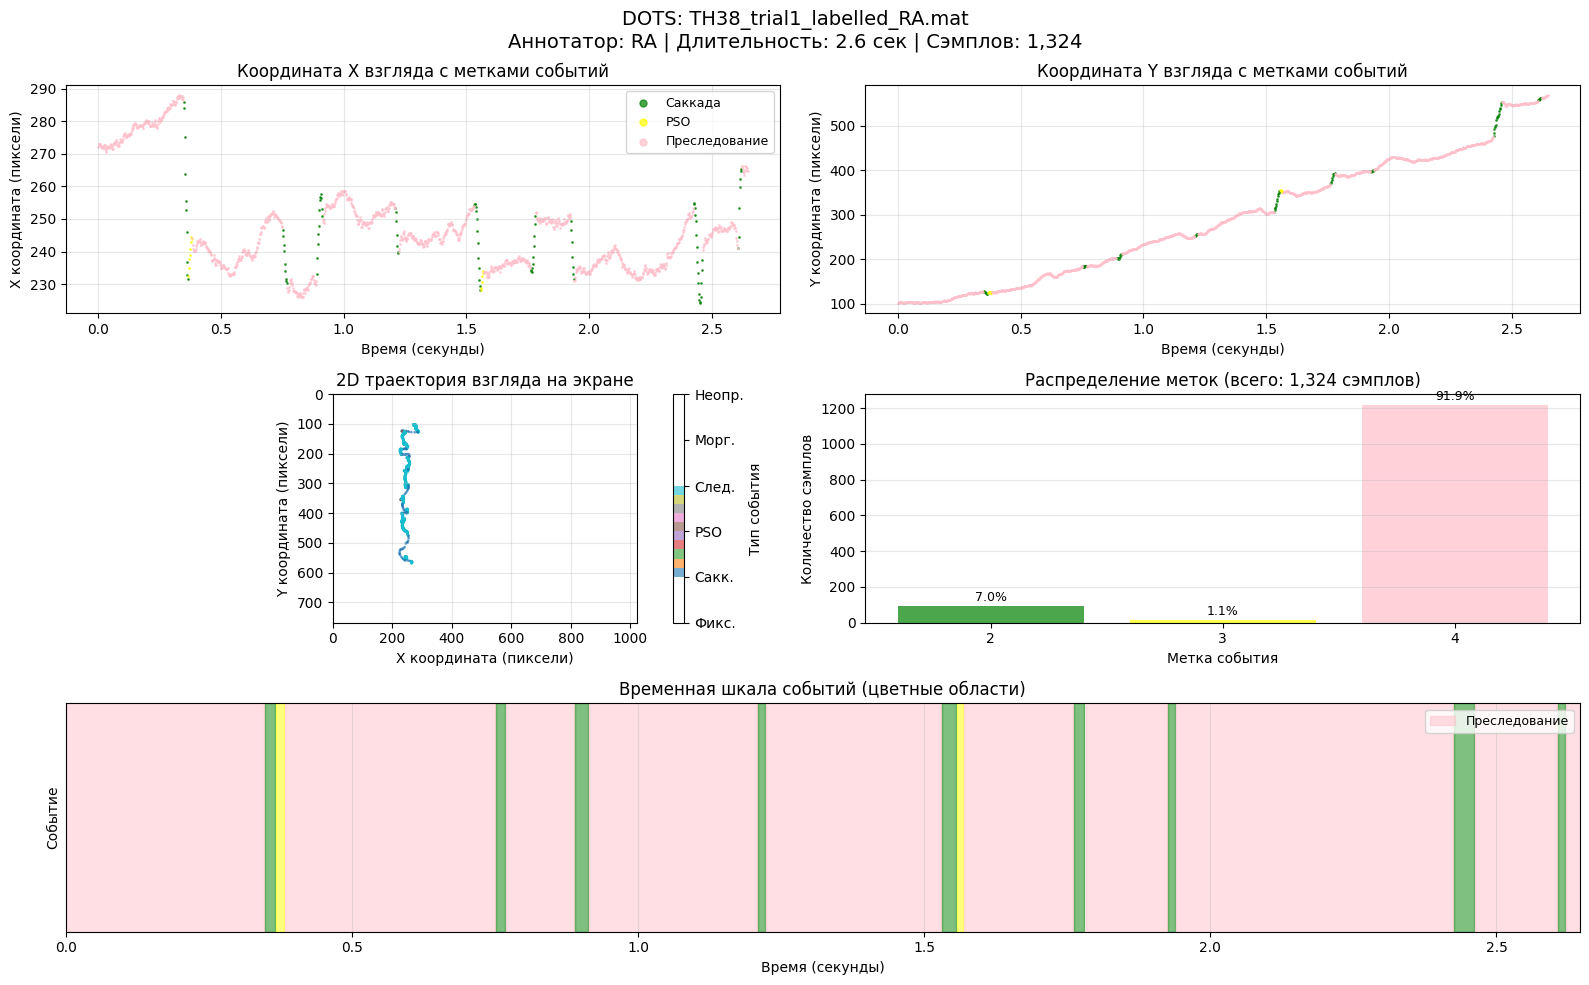


Визуализация файла 2: TH34_img_Europe_labelled_RA.mat


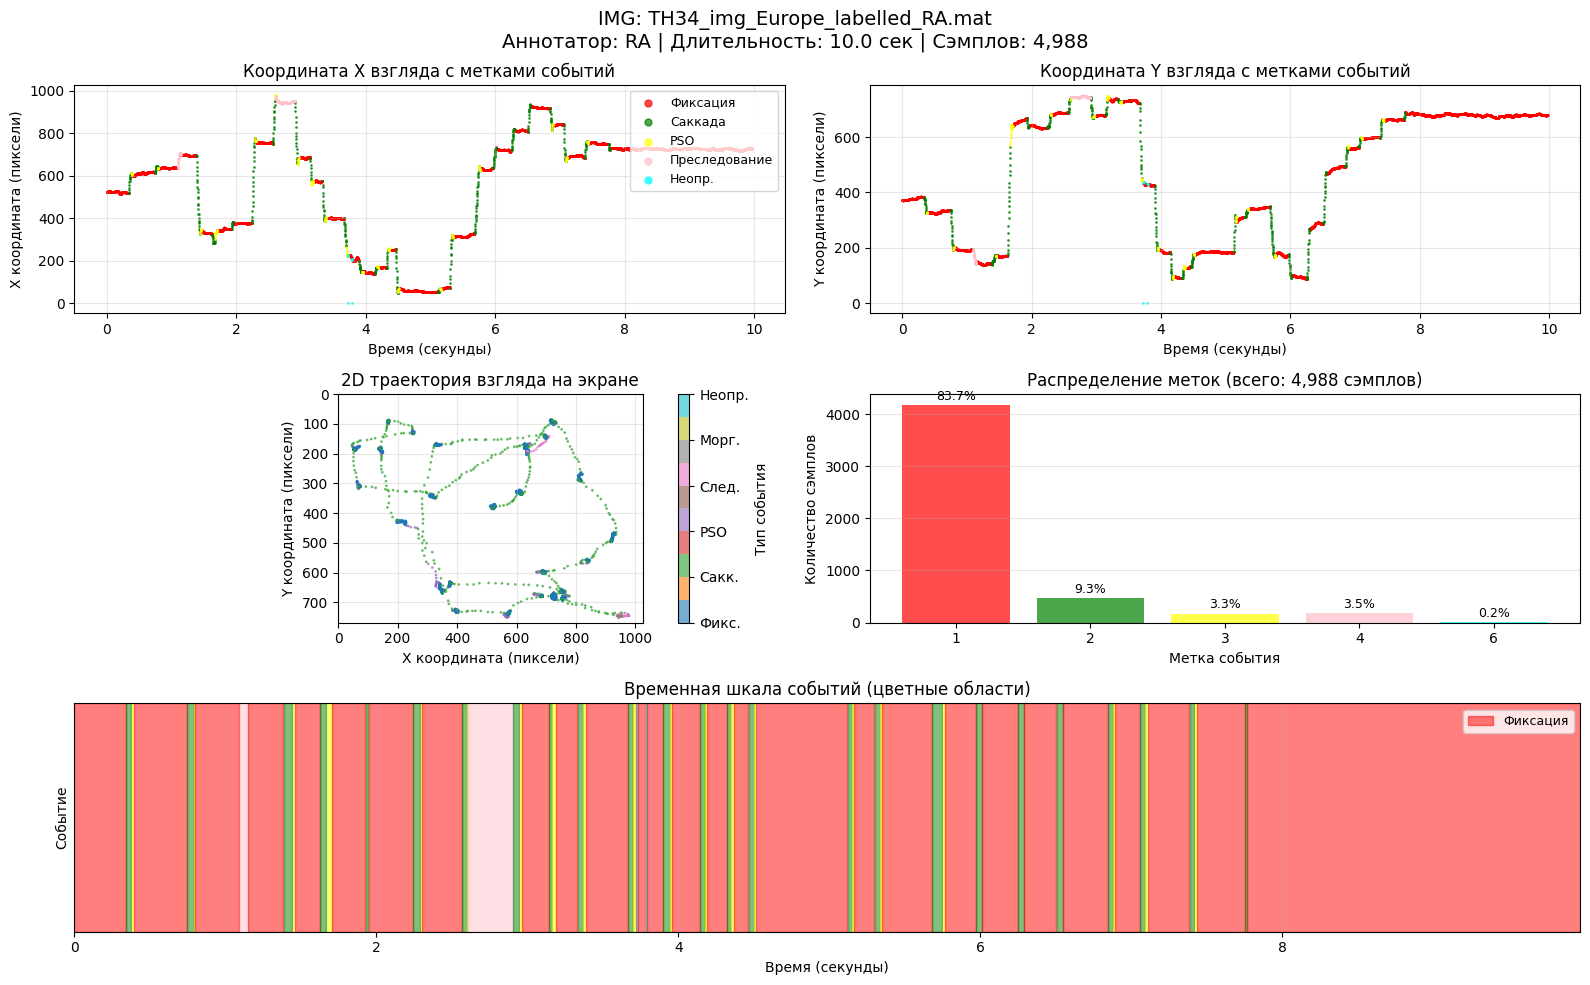


Визуализация файла 3: UL23_video_triple_jump_labelled_RA.mat


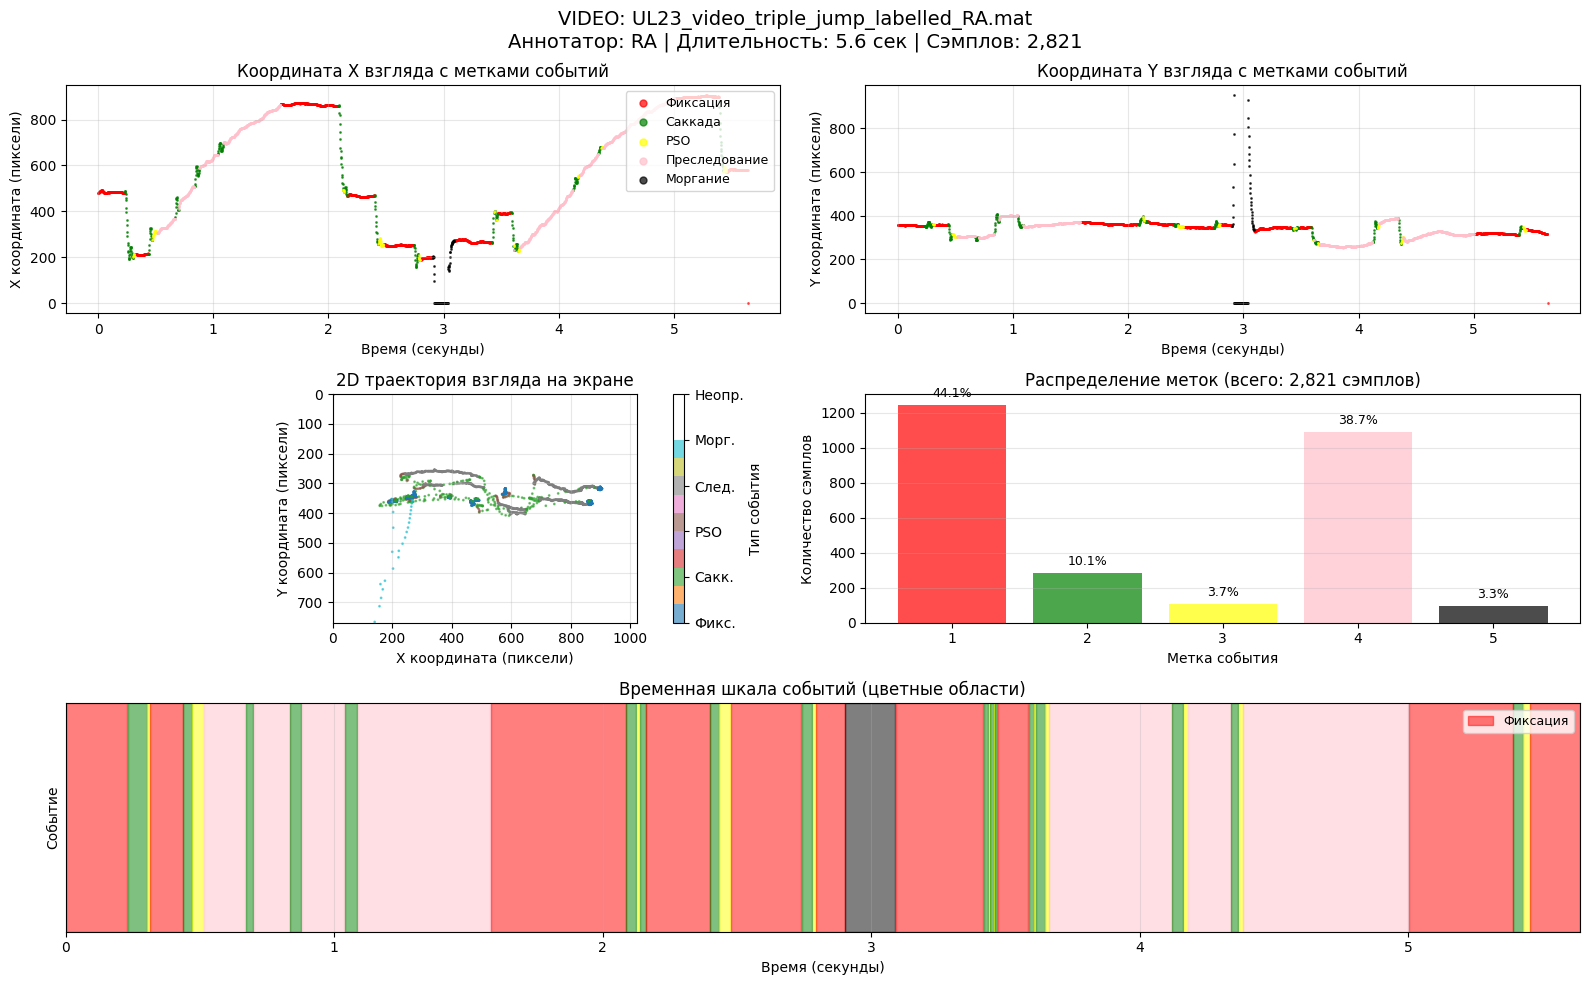

In [ ]:
# ==================== 4. ВИЗУАЛИЗАЦИЯ ДАННЫХ ====================
print("\n🎨 Шаг 3: Визуализация данных...")
print("=" * 60)

if not all_file_info:
    print("Нет данных для визуализации.")
else:
    # Для каждого проанализированного файла создадим графики
    for i, file_info in enumerate(all_file_info[:3]):  # Ограничимся первыми тремя
        print(f"\nВизуализация файла {i+1}: {file_info['filename']}")

        # Создаем фигуру с несколькими графиками
        fig = plt.figure(figsize=(16, 10))
        fig.suptitle(f"{file_info['category'].upper()}: {file_info['filename']}\n"
                    f"Аннотатор: {file_info['annotator']} | "
                    f"Длительность: {file_info['duration_sec']:.1f} сек | "
                    f"Сэмплов: {file_info['samples']:,}", fontsize=14)

        # 1. Временной ряд координаты X с метками
        ax1 = plt.subplot(3, 2, 1)
        time_axis = np.arange(file_info['samples']) / file_info['sampling_freq']

        # Если файл размечен, используем цветовое кодирование
        if file_info['is_labelled'] and file_info['labels'] is not None:
            # Цветовая схема согласно документации датасета
            color_map = {1: 'red', 2: 'green', 3: 'yellow', 4: 'pink', 5: 'black', 6: 'cyan'}
            label_names = {1: 'Фиксация', 2: 'Саккада', 3: 'PSO', 4: 'Преследование', 5: 'Моргание', 6: 'Неопр.'}

            # Разделяем данные по меткам для цветового отображения
            for label in np.unique(file_info['labels']):
                mask = file_info['labels'] == label
                if np.any(mask):
                    ax1.scatter(time_axis[mask], file_info['gaze_x'][mask],
                               c=color_map.get(label, 'gray'), s=1, alpha=0.7,
                               label=label_names.get(label, f'Метка {int(label)}'))
            ax1.legend(loc='upper right', markerscale=5, fontsize=9)
        else:
            # Если нет меток, рисуем простую линию
            ax1.plot(time_axis, file_info['gaze_x'], 'b-', alpha=0.7, linewidth=0.5)

        ax1.set_ylabel('X координата (пиксели)')
        ax1.set_xlabel('Время (секунды)')
        ax1.grid(True, alpha=0.3)
        ax1.set_title('Координата X взгляда с метками событий')

        # 2. Временной ряд координаты Y
        ax2 = plt.subplot(3, 2, 2)
        if file_info['is_labelled'] and file_info['labels'] is not None:
            for label in np.unique(file_info['labels']):
                mask = file_info['labels'] == label
                if np.any(mask):
                    ax2.scatter(time_axis[mask], file_info['gaze_y'][mask],
                               c=color_map.get(label, 'gray'), s=1, alpha=0.7)
        else:
            ax2.plot(time_axis, file_info['gaze_y'], 'g-', alpha=0.7, linewidth=0.5)

        ax2.set_ylabel('Y координата (пиксели)')
        ax2.set_xlabel('Время (секунды)')
        ax2.grid(True, alpha=0.3)
        ax2.set_title('Координата Y взгляда с метками событий')

        # 3. 2D траектория взгляда (X vs Y)
        ax3 = plt.subplot(3, 2, 3)
        if file_info['is_labelled'] and file_info['labels'] is not None:
            scatter = ax3.scatter(file_info['gaze_x'], file_info['gaze_y'],
                                 c=file_info['labels'], cmap='tab10',
                                 s=1, alpha=0.6)
            # Добавляем colorbar для меток
            cbar = plt.colorbar(scatter, ax=ax3)
            cbar.set_label('Тип события')
            cbar.set_ticks([1, 2, 3, 4, 5, 6])
            cbar.set_ticklabels(['Фикс.', 'Сакк.', 'PSO', 'След.', 'Морг.', 'Неопр.'])
        else:
            ax3.plot(file_info['gaze_x'], file_info['gaze_y'], 'b-', alpha=0.5, linewidth=0.5)

        ax3.set_xlabel('X координата (пиксели)')
        ax3.set_ylabel('Y координата (пиксели)')
        ax3.set_xlim(0, file_info['screen_res'][0])
        ax3.set_ylim(file_info['screen_res'][1], 0)  # Инвертируем ось Y (пиксели изображения)
        ax3.grid(True, alpha=0.3)
        ax3.set_title('2D траектория взгляда на экране')
        ax3.set_aspect('equal')

        # 4. Гистограмма распределения меток (только для размеченных файлов)
        ax4 = plt.subplot(3, 2, 4)
        if file_info['is_labelled'] and file_info['label_stats']:
            labels = list(file_info['label_stats'].keys())
            counts = list(file_info['label_stats'].values())
            colors = [color_map.get(l, 'gray') for l in labels]
            bars = ax4.bar([str(l) for l in labels], counts, color=colors, alpha=0.7)

            # Добавляем подписи с процентами
            total = sum(counts)
            for bar, count in zip(bars, counts):
                height = bar.get_height()
                percentage = (count / total) * 100
                ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01*total,
                        f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)

            ax4.set_xlabel('Метка события')
            ax4.set_ylabel('Количество сэмплов')
            ax4.set_title(f'Распределение меток (всего: {total:,} сэмплов)')
            ax4.grid(True, alpha=0.3, axis='y')
        else:
            ax4.text(0.5, 0.5, 'Файл не размечен\nнет данных о метках',
                    ha='center', va='center', transform=ax4.transAxes, fontsize=12)
            ax4.set_title('Распределение меток')

        # 5. Временная шкала событий (цветные полосы по времени)
        ax5 = plt.subplot(3, 1, 3)
        if file_info['is_labelled'] and file_info['labels'] is not None:
            # Находим границы между событиями
            labels = file_info['labels']
            changes = np.diff(labels, prepend=labels[0]-1, append=labels[-1]-1)
            change_points = np.where(changes != 0)[0]

            # Рисуем цветные полосы для каждого события
            for j in range(len(change_points) - 1):
                start_idx = change_points[j]
                end_idx = change_points[j + 1]
                label = int(labels[start_idx])
                ax5.axvspan(time_axis[start_idx], time_axis[end_idx-1] if end_idx < len(time_axis) else time_axis[-1],
                           alpha=0.5, color=color_map.get(label, 'gray'),
                           label=label_names.get(label, f'Метка {label}') if j == 0 else "")

            ax5.set_xlabel('Время (секунды)')
            ax5.set_ylabel('Событие')
            ax5.set_yticks([])
            ax5.set_xlim(time_axis[0], time_axis[-1])
            ax5.grid(True, alpha=0.3, axis='x')
            ax5.set_title('Временная шкала событий (цветные области)')

            # Убираем повторения в легенде
            handles, labels_leg = ax5.get_legend_handles_labels()
            by_label = dict(zip(labels_leg, handles))
            if by_label:
                ax5.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9)
        else:
            ax5.text(0.5, 0.5, 'Нет данных о метках для временной шкалы',
                    ha='center', va='center', transform=ax5.transAxes, fontsize=12)
            ax5.set_title('Временная шкала событий')

        plt.tight_layout()
        plt.savefig(f"visualization_{file_info['category']}_{i+1}.png", dpi=120, bbox_inches='tight')
        plt.show()

In [ ]:
# ==================== 5. ПОДГОТОВКА ДАННЫХ ДЛЯ МАШИННОГО ОБУЧЕНИЯ ====================
print("\n🤖 Шаг 4: Подготовка данных для обучения классификатора...")
print("=" * 60)

# Соберем все размеченные данные для обучения
X_all = []  # Признаки
y_all = []  # Метки
file_sources = []  # Информация о происхождении данных

for file_info in all_file_info:
    if file_info['is_labelled'] and file_info['labels'] is not None:
        # Берем только фиксации (1) и саккады (2) для бинарной классификации
        mask = (file_info['labels'] == 1) | (file_info['labels'] == 2)

        if np.any(mask):
            # Признаки: X и Y координаты, а также их производные (скорость)
            gaze_x = file_info['gaze_x'][mask]
            gaze_y = file_info['gaze_y'][mask]
            labels = file_info['labels'][mask]

            # Простые признаки: координаты
            features_basic = np.column_stack((gaze_x, gaze_y))

            # Более сложные признаки: скорость (производная координат)
            if len(gaze_x) > 1:
                # Вычисляем скорость по X и Y (разность между последовательными сэмплами)
                # Учитываем частоту дискретизации для перевода в пиксели/секунду
                dt = 1.0 / file_info['sampling_freq']
                velocity_x = np.abs(np.gradient(gaze_x, dt))
                velocity_y = np.abs(np.gradient(gaze_y, dt))
                speed = np.sqrt(velocity_x**2 + velocity_y**2)

                # Объединяем все признаки
                features = np.column_stack((gaze_x, gaze_y, velocity_x, velocity_y, speed))
            else:
                features = features_basic

            X_all.append(features)
            y_all.append(labels)
            file_sources.extend([file_info['filename']] * len(labels))

            print(f"✅ {file_info['filename']}: добавлено {len(labels)} сэмплов ("
                  f"Фиксаций: {np.sum(labels == 1)}, "
                  f"Саккад: {np.sum(labels == 2)})")

# Объединяем все данные
if X_all:
    X_combined = np.vstack(X_all)
    y_combined = np.hstack(y_all)
    print(f"\n📊 ИТОГО для обучения классификатора:")
    print(f"   Всего сэмплов: {X_combined.shape[0]:,}")
    print(f"   Всего признаков: {X_combined.shape[1]}")
    print(f"   Фиксаций (метка 1): {np.sum(y_combined == 1):,} ({np.sum(y_combined == 1)/len(y_combined)*100:.1f}%)")
    print(f"   Саккад (метка 2): {np.sum(y_combined == 2):,} ({np.sum(y_combined == 2)/len(y_combined)*100:.1f}%)")

    # Сохраняем данные для дальнейшего использования
    np.savez('eye_movement_data.npz',
             X=X_combined,
             y=y_combined,
             sources=file_sources,
             feature_names=['gaze_x', 'gaze_y', 'velocity_x', 'velocity_y', 'speed'])

    print("\n💾 Данные сохранены в файл: 'eye_movement_data.npz'")
    print("\n🎯 Теперь вы можете использовать эти данные для обучения модели:")
    print("""
    # Пример загрузки данных
    data = np.load('eye_movement_data.npz')
    X = data['X']
    y = data['y']

    # Разделение на тренировочную и тестовую выборки
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Обучение модели (например, RandomForest)
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Оценка точности
    accuracy = model.score(X_test, y_test)
    print(f"Точность модели: {accuracy:.3f}")
    """)
else:
    print("❌ Не найдено размеченных данных для обучения.")

print("\n" + "=" * 60)
print("✅ Анализ завершен! Проверьте файлы визуализации (*.png)")
print("   и подготовленный датасет для ML (eye_movement_data.npz)")
print("=" * 60)

In [ ]:
# ==================== ТАБЛИЧНОЕ ПРЕДСТАВЛЕНИЕ ДАННЫХ ====================
print("\n📋 Шаг 2.5: Табличное представление структуры данных")
print("=" * 60)

def display_file_structure_table(file_info, sample_rows=5):
    """
    Выводит структуру файла в виде таблиц
    """
    print(f"\n📁 ФАЙЛ: {file_info['filename']}")
    print(f"📂 Категория: {file_info['category']} | Аннотатор: {file_info['annotator']}")
    print("-" * 80)

    # 1. ТАБЛИЦА: ОСНОВНЫЕ ПАРАМЕТРЫ ФАЙЛА
    print("📊 ОСНОВНЫЕ ПАРАМЕТРЫ:")
    params_data = [
        ["Сэмплов", f"{file_info['samples']:,}"],
        ["Длительность", f"{file_info['duration_sec']:.2f} сек"],
        ["Частота дискретизации", f"{file_info['sampling_freq']} Гц"],
        ["Разрешение экрана", f"{file_info['screen_res'][0]}×{file_info['screen_res'][1]}"],
        ["Размечен", "ДА" if file_info['is_labelled'] else "НЕТ"],
        ["Аннотатор", file_info['annotator']]
    ]

    # Форматируем как таблицу
    print("┌" + "─"*30 + "┬" + "─"*30 + "┐")
    print("│ {:28} │ {:28} │".format("Параметр", "Значение"))
    print("├" + "─"*30 + "┼" + "─"*30 + "┤")
    for param, value in params_data:
        print("│ {:28} │ {:28} │".format(param, str(value)))
    print("└" + "─"*30 + "┴" + "─"*30 + "┘")

    # 2. ТАБЛИЦА: СТРУКТУРА СТОЛБЦОВ МАТРИЦЫ pos
    print("\n📈 СТРУКТУРА МАТРИЦЫ ДАННЫХ (ETdata['pos']):")
    columns_info = [
        ["0", "timestamp", "Время (микросекунды)", "uint64/float64"],
        ["1", "pupil_diameter_x", "Диаметр зрачка X", "float64"],
        ["2", "pupil_diameter_y", "Диаметр зрачка Y", "float64"],
        ["3", "gaze_x", "Координата X взгляда", "float64"],
        ["4", "gaze_y", "Координата Y взгляда", "float64"],
        ["5", "label", "Метка события (1-6)", "int64"]
    ]

    print("┌" + "─"*5 + "┬" + "─"*20 + "┬" + "─"*35 + "┬" + "─"*15 + "┐")
    print("│ {:3} │ {:18} │ {:33} │ {:13} │".format("Индекс", "Имя", "Описание", "Тип данных"))
    print("├" + "─"*5 + "┼" + "─"*20 + "┼" + "─"*35 + "┼" + "─"*15 + "┤")
    for idx, name, desc, dtype in columns_info:
        print("│ {:3} │ {:18} │ {:33} │ {:13} │".format(idx, name, desc, dtype))
    print("└" + "─"*5 + "┴" + "─"*20 + "┴" + "─"*35 + "┴" + "─"*15 + "┘")

    # 3. ТАБЛИЦА: ЗНАЧЕНИЯ МЕТОК (если файл размечен)
    if file_info['is_labelled'] and file_info['label_stats']:
        print("\n🏷️  РАСПРЕДЕЛЕНИЕ МЕТОК СОБЫТИЙ:")
        label_names = {
            1: "Фиксация (Fixation)",
            2: "Саккада (Saccade)",
            3: "Пост-саккад. колебания (PSO)",
            4: "Плавное слежение (Pursuit)",
            5: "Моргание (Blink)",
            6: "Неопределено (Undefined)"
        }

        total = file_info['samples']
        print("┌" + "─"*10 + "┬" + "─"*40 + "┬" + "─"*12 + "┬" + "─"*12 + "┬" + "─"*10 + "┐")
        print("│ {:8} │ {:38} │ {:10} │ {:10} │ {:8} │".format(
            "Код", "Тип события", "Кол-во", "Процент", "Длит. (с)"
        ))
        print("├" + "─"*10 + "┼" + "─"*40 + "┼" + "─"*12 + "┼" + "─"*12 + "┼" + "─"*10 + "┤")

        for label_code, count in sorted(file_info['label_stats'].items()):
            percentage = (count / total) * 100
            duration_sec = count / file_info['sampling_freq']
            name = label_names.get(int(label_code), f"Неизвестно ({label_code})")

            print("│ {:8} │ {:38} │ {:10,} │ {:9.1f}% │ {:8.2f} │".format(
                f"{int(label_code)}",
                name[:38],
                count,
                percentage,
                duration_sec
            ))
        print("└" + "─"*10 + "┴" + "─"*40 + "┴" + "─"*12 + "┴" + "─"*12 + "┴" + "─"*10 + "┘")

    # 4. ТАБЛИЦА: ПЕРВЫЕ N СТРОК ДАННЫХ (образец)
    print(f"\n📊 ПЕРВЫЕ {sample_rows} СТРОК ДАННЫХ:")

    # Создаем мини-таблицу с данными
    data_sample = file_info['data'][:sample_rows]

    # Заголовки столбцов
    headers = ["Время (мкс)", "Зрачок X", "Зрачок Y", "Взгляд X", "Взгляд Y", "Метка"]

    # Определяем ширины столбцов
    col_widths = [15, 12, 12, 12, 12, 8]

    # Верхняя граница
    top_border = "┌"
    for width in col_widths:
        top_border += "─" * (width + 2) + "┬"
    top_border = top_border[:-1] + "┐"
    print(top_border)

    # Заголовок
    header_row = "│"
    for header, width in zip(headers, col_widths):
        header_row += f" {header:{width}} │"
    print(header_row)

    # Разделитель
    sep_border = "├"
    for width in col_widths:
        sep_border += "─" * (width + 2) + "┼"
    sep_border = sep_border[:-1] + "┤"
    print(sep_border)

    # Данные
    for i, row in enumerate(data_sample):
        data_row = "│"
        for j, value in enumerate(row):
            if j == 0:  # Время
                formatted = f"{value:,.0f}" if value > 1000 else f"{value:.2f}"
            elif j == 5:  # Метка
                formatted = f"{int(value)}" if not np.isnan(value) else "NaN"
            else:  # Координаты
                formatted = f"{value:.1f}"
            data_row += f" {formatted:>{col_widths[j]}} │"
        print(data_row)

    # Нижняя граница
    bottom_border = "└"
    for width in col_widths:
        bottom_border += "─" * (width + 2) + "┴"
    bottom_border = bottom_border[:-1] + "┘"
    print(bottom_border)

    # 5. СВОДНАЯ СТАТИСТИКА ПО КООРДИНАТАМ
    print("\n📈 СТАТИСТИКА ПО КООРДИНАТАМ ВЗГЛЯДА:")
    gaze_x = file_info['gaze_x']
    gaze_y = file_info['gaze_y']

    stats_data = [
        ["Метрика", "X координата", "Y координата"],
        ["Минимум", f"{np.min(gaze_x):.1f}", f"{np.min(gaze_y):.1f}"],
        ["Максимум", f"{np.max(gaze_x):.1f}", f"{np.max(gaze_y):.1f}"],
        ["Среднее", f"{np.mean(gaze_x):.1f}", f"{np.mean(gaze_y):.1f}"],
        ["Станд. отклон.", f"{np.std(gaze_x):.1f}", f"{np.std(gaze_y):.1f}"],
        ["Медиана", f"{np.median(gaze_x):.1f}", f"{np.median(gaze_y):.1f}"]
    ]

    print("┌" + "─"*20 + "┬" + "─"*15 + "┬" + "─"*15 + "┐")
    for i, row in enumerate(stats_data):
        if i == 0:
            print("│ {:18} │ {:13} │ {:13} │".format(row[0], row[1], row[2]))
            print("├" + "─"*20 + "┼" + "─"*15 + "┼" + "─"*15 + "┤")
        else:
            print("│ {:18} │ {:>13} │ {:>13} │".format(row[0], row[1], row[2]))
    print("└" + "─"*20 + "┴" + "─"*15 + "┴" + "─"*15 + "┘")

# ==================== ВЫВОД СВОДНОЙ ТАБЛИЦЫ ПО ВСЕМ ФАЙЛАМ ====================
print("\n📋 СВОДНАЯ ТАБЛИЦА ПО ВСЕМ ПРОАНАЛИЗИРОВАННЫМ ФАЙЛАМ:")
print("=" * 80)

# Создаем сводную таблицу
summary_headers = ["№", "Категория", "Файл", "Сэмплов", "Длит. (с)", "Фикс.", "Сакк.", "Др.", "Аннот."]
print("┌" + "─"*5 + "┬" + "─"*10 + "┬" + "─"*35 + "┬" + "─"*10 + "┬" + "─"*10 + "┬" + "─"*8 + "┬" + "─"*8 + "┬" + "─"*8 + "┬" + "─"*8 + "┐")
print("│ {:3} │ {:8} │ {:33} │ {:8} │ {:8} │ {:6} │ {:6} │ {:6} │ {:6} │".format(*summary_headers))
print("├" + "─"*5 + "┼" + "─"*10 + "┼" + "─"*35 + "┼" + "─"*10 + "┼" + "─"*10 + "┼" + "─"*8 + "┼" + "─"*8 + "┼" + "─"*8 + "┼" + "─"*8 + "┤")

for i, file_info in enumerate(all_file_info, 1):
    filename_short = file_info['filename'][:30] + "..." if len(file_info['filename']) > 30 else file_info['filename']

    # Считаем распределение меток
    fix_count = file_info['label_stats'].get(1, 0) if file_info['label_stats'] else 0
    sacc_count = file_info['label_stats'].get(2, 0) if file_info['label_stats'] else 0
    other_count = file_info['samples'] - (fix_count + sacc_count)

    print("│ {:3} │ {:8} │ {:33} │ {:8,} │ {:8.1f} │ {:6} │ {:6} │ {:6} │ {:6} │".format(
        i,
        file_info['category'][:8],
        filename_short[:33],
        file_info['samples'],
        file_info['duration_sec'],
        fix_count,
        sacc_count,
        other_count,
        file_info['annotator']
    ))

print("└" + "─"*5 + "┴" + "─"*10 + "┴" + "─"*35 + "┴" + "─"*10 + "┴" + "─"*10 + "┴" + "─"*8 + "┴" + "─"*8 + "┴" + "─"*8 + "┴" + "─"*8 + "┘")

# ==================== ТАБЛИЦА ДЛЯ ML-ПРИЗНАКОВ ====================
print("\n🤖 ТАБЛИЦА ПРИЗНАКОВ ДЛЯ МАШИННОГО ОБУЧЕНИЯ:")
print("=" * 80)

ml_features = [
    ["gaze_x", "float", "Горизонтальная координата взгляда (пиксели)", "Основной признак"],
    ["gaze_y", "float", "Вертикальная координата взгляда (пиксели)", "Основной признак"],
    ["velocity_x", "float", "Горизонтальная скорость (пикс/сек)", "Ключевой! Саккады >200°/с"],
    ["velocity_y", "float", "Вертикальная скорость (пикс/сек)", "Ключевой! Саккады >200°/с"],
    ["speed", "float", "Общая скорость движения (пикс/сек)", "Главный дифференцирующий признак"]
]

print("┌" + "─"*15 + "┬" + "─"*10 + "┬" + "─"*40 + "┬" + "─"*30 + "┐")
print("│ {:13} │ {:8} │ {:38} │ {:28} │".format("Признак", "Тип", "Описание", "Роль в классификации"))
print("├" + "─"*15 + "┼" + "─"*10 + "┼" + "─"*40 + "┼" + "─"*30 + "┤")

for feature in ml_features:
    print("│ {:13} │ {:8} │ {:38} │ {:28} │".format(
        feature[0], feature[1], feature[2][:38], feature[3][:28]
    ))

print("└" + "─"*15 + "┴" + "─"*10 + "┴" + "─"*40 + "┴" + "─"*30 + "┘")

# Выводим детальную структуру для первого файла
if all_file_info:
    print("\n" + "="*80)
    print("🔍 ДЕТАЛЬНАЯ СТРУКТУРА ПЕРВОГО ФАЙЛА:")
    print("="*80)
    display_file_structure_table(all_file_info[0])


📋 Шаг 2.5: Табличное представление структуры данных

📋 СВОДНАЯ ТАБЛИЦА ПО ВСЕМ ПРОАНАЛИЗИРОВАННЫМ ФАЙЛАМ:
┌─────┬──────────┬───────────────────────────────────┬──────────┬──────────┬────────┬────────┬────────┬────────┐
│ №   │ Категория │ Файл                              │ Сэмплов  │ Длит. (с) │ Фикс.  │ Сакк.  │ Др.    │ Аннот. │
├─────┼──────────┼───────────────────────────────────┼──────────┼──────────┼────────┼────────┼────────┼────────┤
│   1 │ dots     │ TH38_trial1_labelled_RA.mat       │    1,324 │      2.6 │      0 │     93 │   1231 │ RA     │
│   2 │ img      │ TH34_img_Europe_labelled_RA.ma... │    4,988 │     10.0 │   4173 │    466 │    349 │ RA     │
│   3 │ video    │ UL23_video_triple_jump_labelle... │    2,821 │      5.6 │   1245 │    284 │   1292 │ RA     │
└─────┴──────────┴───────────────────────────────────┴──────────┴──────────┴────────┴────────┴────────┴────────┘

🤖 ТАБЛИЦА ПРИЗНАКОВ ДЛЯ МАШИННОГО ОБУЧЕНИЯ:
┌───────────────┬──────────┬───────────────────────────

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat

def extract_mat_structure_to_dataframe(root_dir):
    """
    Извлекает ИСХОДНУЮ структуру .mat файлов в таблицу
    Каждая строка = один сэмпл с исходными полями
    """
    print(f"📂 Извлечение данных из: {root_dir}")

    all_records = []

    categories = ['dots', 'img', 'video']

    for category in categories:
        category_path = os.path.join(root_dir, category)

        if not os.path.exists(category_path):
            continue

        mat_files = [f for f in os.listdir(category_path) if f.endswith('.mat')]
        print(f"\n📁 {category}: {len(mat_files)} файлов")

        for filename in mat_files:
            file_path = os.path.join(category_path, filename)

            try:
                # Загружаем файл
                mat_data = loadmat(file_path, simplify_cells=True)
                et_data = mat_data['ETdata']

                # Извлекаем ВСЕ поля из структуры
                pos_matrix = et_data['pos']  # n x 5 или n x 6

                # Определяем аннотатора
                annotator = "MN" if "_MN." in filename else "RA" if "_RA." in filename else "Unknown"

                # Для КАЖДОГО сэмпла создаем запись
                for i in range(len(pos_matrix)):
                    record = {
                        # МЕТАДАННЫЕ ФАЙЛА
                        'file_name': filename,
                        'file_category': category,
                        'file_annotator': annotator,

                        # ПОЛЯ ИЗ ETdata (исходная структура)
                        'sampFreq': et_data['sampFreq'],
                        'viewDist': et_data['viewDist'] if 'viewDist' in et_data else np.nan,
                        'screenDim_x': et_data['screenDim'][0] if 'screenDim' in et_data else np.nan,
                        'screenDim_y': et_data['screenDim'][1] if 'screenDim' in et_data else np.nan,
                        'screenRes_x': et_data['screenRes'][0],
                        'screenRes_y': et_data['screenRes'][1],

                        # ПОЛЯ ИЗ pos МАТРИЦЫ (n x 5 или n x 6)
                        'timestamp_us': pos_matrix[i, 0],        # микросекунды
                        'pupil_diameter_horizontal': pos_matrix[i, 1],
                        'pupil_diameter_vertical': pos_matrix[i, 2],
                        'gaze_x': pos_matrix[i, 3],              # координата X
                        'gaze_y': pos_matrix[i, 4],              # координата Y

                        # МЕТКА (если есть, 6-й столбец)
                        'label': int(pos_matrix[i, 5]) if pos_matrix.shape[1] >= 6 else -1,

                        # Индекс сэмпла
                        'sample_index': i,
                    }

                    # Вычисляем время в секундах
                    if i == 0:
                        time_zero = pos_matrix[i, 0]

                    record['timestamp_s'] = (pos_matrix[i, 0] - time_zero) / 1_000_000.0

                    all_records.append(record)

                print(f"  ✓ {filename}: {len(pos_matrix)} сэмплов")

            except Exception as e:
                print(f"  ✗ Ошибка в {filename}: {e}")

    # Создаем DataFrame
    df = pd.DataFrame(all_records)

    print(f"\n✅ ГОТОВО! Таблица создана:")
    print(f"   Всего записей: {len(df):,}")
    print(f"   Файлов обработано: {len(df['file_name'].unique())}")
    print(f"   Столбцов: {len(df.columns)}")

    # Показываем структуру
    print(f"\n📋 СТРУКТУРА ТАБЛИЦЫ:")
    for col in df.columns:
        dtype = str(df[col].dtype)
        non_null = df[col].notna().sum()
        print(f"  {col:30} {dtype:10} ({non_null:,} not null)")

    return df

# ==================== ИСПОЛЬЗОВАНИЕ ====================

# 1. Извлекаем данные
DATA_DIR = "/content/drive/MyDrive/data used in the article"
df_raw = extract_mat_structure_to_dataframe(DATA_DIR)

# 2. Сохраняем в CSV
if len(df_raw) > 0:
    output_file = "eye_tracking_raw_data.csv"
    df_raw.to_csv(output_file, index=False)
    print(f"\n💾 Данные сохранены в: {output_file}")

    # 3. Пример: смотрим первые записи
    print("\n🔍 ПЕРВЫЕ 3 ЗАПИСИ ИЗ ТАБЛИЦЫ:")
    print(df_raw[['file_name', 'timestamp_s', 'gaze_x', 'gaze_y', 'label']].head(3).to_string())

    # 4. Статистика по меткам
    if 'label' in df_raw.columns:
        print("\n📊 СТАТИСТИКА ПО МЕТКАМ:")
        label_stats = df_raw['label'].value_counts().sort_index()
        label_names = {
            1: 'Фиксация', 2: 'Саккада', 3: 'PSO',
            4: 'Плавное слежение', 5: 'Моргание', 6: 'Неопределено', -1: 'Нет метки'
        }

        for label, count in label_stats.items():
            name = label_names.get(label, f'Метка {label}')
            percentage = count / len(df_raw) * 100
            print(f"  {name:20} ({label}): {count:8,} ({percentage:.1f}%)")

📂 Извлечение данных из: /content/drive/MyDrive/data used in the article

📁 dots: 22 файлов
  ✓ TH38_trial1_labelled_RA.mat: 1324 сэмплов
  ✓ UL27_trial17_labelled_MN.mat: 454 сэмплов
  ✓ UH21_trial1_labelled_RA.mat: 1658 сэмплов
  ✓ UL27_trial17_labelled_RA.mat: 455 сэмплов
  ✓ UH21_trial1_labelled_MN.mat: 1658 сэмплов
  ✓ UH33_trial17_labelled_RA.mat: 453 сэмплов
  ✓ UH21_trial17_labelled_RA.mat: 565 сэмплов
  ✓ TL22_trial17_labelled_RA.mat: 453 сэмплов
  ✓ UL31_trial1_labelled_MN.mat: 1326 сэмплов
  ✓ UL39_trial1_labelled_RA.mat: 1327 сэмплов
  ✓ TH38_trial1_labelled_MN.mat: 1324 сэмплов
  ✓ TL24_trial17_labelled_MN.mat: 453 сэмплов
  ✓ TL22_trial17_labelled_MN.mat: 453 сэмплов
  ✓ TH20_trial1_labelled_RA.mat: 1658 сэмплов
  ✓ TL24_trial17_labelled_RA.mat: 453 сэмплов
  ✓ UH25_trial1_labelled_RA.mat: 1326 сэмплов
  ✓ UH21_trial17_labelled_MN.mat: 565 сэмплов
  ✓ UH33_trial17_labelled_MN.mat: 453 сэмплов
  ✓ UH25_trial1_labelled_MN.mat: 1326 сэмплов
  ✓ UL39_trial1_labelled_MN.mat: 13

In [ ]:
# Загружаем CSV файл как DataFrame (таблицу)
df = pd.read_csv('eye_tracking_raw_data.csv')

# Проверяем успешность загрузки
print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")


✅ Файл загружен успешно!
📊 Размер датасета: 207,766 строк × 17 столбцов
📋 Столбцы: ['file_name', 'file_category', 'file_annotator', 'sampFreq', 'viewDist', 'screenDim_x', 'screenDim_y', 'screenRes_x', 'screenRes_y', 'timestamp_us', 'pupil_diameter_horizontal', 'pupil_diameter_vertical', 'gaze_x', 'gaze_y', 'label', 'sample_index', 'timestamp_s']


In [ ]:
df.head()

,file_name,file_category,file_annotator,sampFreq,viewDist,screenDim_x,screenDim_y,screenRes_x,screenRes_y,timestamp_us,pupil_diameter_horizontal,pupil_diameter_vertical,gaze_x,gaze_y,label,sample_index,timestamp_s
0,TH38_trial1_labelled_RA.mat,dots,RA,500,0.67,0.38,0.3,1024,768,NaN,18.0,17.0,272.2101,102.4636,4,0,NaN
1,TH38_trial1_labelled_RA.mat,dots,RA,500,0.67,0.38,0.3,1024,768,NaN,18.0,16.0,272.5732,102.7934,4,1,NaN
2,TH38_trial1_labelled_RA.mat,dots,RA,500,0.67,0.38,0.3,1024,768,NaN,18.0,16.0,273.0682,102.9408,4,2,NaN
3,TH38_trial1_labelled_RA.mat,dots,RA,500,0.67,0.38,0.3,1024,768,NaN,18.0,17.0,272.9033,103.0184,4,3,NaN
4,TH38_trial1_labelled_RA.mat,dots,RA,500,0.67,0.38,0.3,1024,768,NaN,18.0,17.0,272.8533,103.0873,4,4,NaN


In [ ]:
df.tail()

,file_name,file_category,file_annotator,sampFreq,viewDist,screenDim_x,screenDim_y,screenRes_x,screenRes_y,timestamp_us,pupil_diameter_horizontal,pupil_diameter_vertical,gaze_x,gaze_y,label,sample_index,timestamp_s
207761,TL30_video_triple_jump_labelled_MN.mat,video,MN,500,0.67,0.38,0.3,1024,768,3.381869e+09,21.0,22.0,505.8395,434.6408,1,2815,5.631181
207762,TL30_video_triple_jump_labelled_MN.mat,video,MN,500,0.67,0.38,0.3,1024,768,3.381871e+09,22.0,22.0,504.7636,434.8709,1,2816,5.633180
207763,TL30_video_triple_jump_labelled_MN.mat,video,MN,500,0.67,0.38,0.3,1024,768,3.381873e+09,21.0,22.0,500.8424,436.4656,1,2817,5.635179
207764,TL30_video_triple_jump_labelled_MN.mat,video,MN,500,0.67,0.38,0.3,1024,768,3.381875e+09,21.0,22.0,501.9947,437.0220,1,2818,5.637180
207765,TL30_video_triple_jump_labelled_MN.mat,video,MN,500,0.67,0.38,0.3,1024,768,3.381877e+09,21.0,22.0,502.7849,436.5580,1,2819,5.639180


# CNN

🚀 ЗАПУСК ПАЙПЛАЙНА КЛАССИФИКАЦИИ...
✅ Данные подготовлены: 139,357 записей
📊 Создано последовательностей: (27627, 20, 3)
📁 Всего файлов: 68

📊 РАЗМЕРЫ ДАННЫХ:
  Train: 18,050 последовательностей (форма: (18050, 20, 3))
  Val:   4,513 последовательностей (форма: (4513, 20, 3))
  Test:  5,064 последовательностей (форма: (5064, 20, 3))

🔧 ПОДГОТОВКА ДАННЫХ ДЛЯ CNN...
   X_train shape: (18050, 20, 3)
   X_val shape: (4513, 20, 3)

📊 БАЛАНС КЛАССОВ:
   Train - Фиксации: 16130 (89.4%), Саккады: 1920 (10.6%)
   Val   - Фиксации: 4010 (88.9%), Саккады: 503 (11.1%)

🧠 СОЗДАНИЕ CNN МОДЕЛИ...
✅ Модель создана. Архитектура:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,249 (270.50 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 384 (1.50 KB)


🎯 НАЧАЛО ОБУЧЕНИЯ...
Epoch 1/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9563 - loss: 0.1466 - precision: 0.8532 - recall: 0.7251 - val_accuracy: 0.9743 - val_loss: 0.0772 - val_precision: 0.9253 - val_recall: 0.8370 - learning_rate: 0.0010
Epoch 2/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9769 - loss: 0.0782 - precision: 0.9180 - recall: 0.8586 - val_accuracy: 0.9716 - val_loss: 0.0849 - val_precision: 0.8743 - val_recall: 0.8708 - learning_rate: 0.0010
Epoch 3/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9808 - loss: 0.0626 - precision: 0.9288 - recall: 0.8855 - val_accuracy: 0.9761 - val_loss: 0.0740 - val_precision: 0.9229 - val_recall: 0.8569 - learning_rate: 0.0010
Epoch 4/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9796 - loss: 0.0662 - precision: 0.9357 - recall: 0.8757 - val_accuracy: 0.9787 - val_loss: 0.0696 - val_precision: 0.9414 - val_recall: 0.8628 - learning_rate: 0.0010
Epoch 5/30
565/565 ━━━━━━━━━━━━━━━━━━━

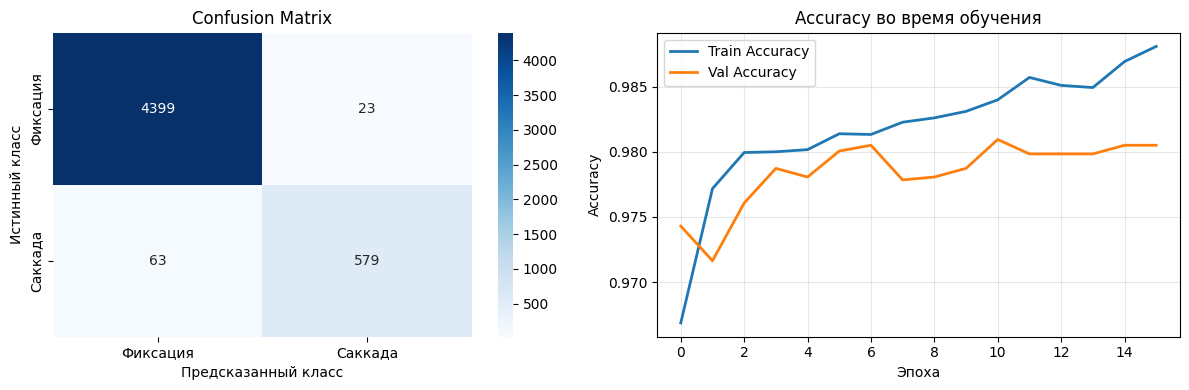

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras

# 1. Загрузка и подготовка данных
df = pd.read_csv('eye_tracking_raw_data.csv')

# 2. Создание признаков
def create_features(df):
    """Создает все необходимые признаки"""
    df = df.copy()

    # Базовые признаки
    if 'velocity_x' not in df.columns:
        dt = 1/500  # 500 Гц
        df['velocity_x'] = np.gradient(df['gaze_x'], dt)
        df['velocity_y'] = np.gradient(df['gaze_y'], dt)
        df['speed'] = np.sqrt(df['velocity_x']**2 + df['velocity_y']**2)
        df['acceleration'] = np.gradient(df['speed'], dt)

    # Только фиксации и саккады
    df = df[df['label'].isin([1, 2])].copy()

    return df

# 3. Создание окон для временных рядов
def create_sequences(data, window_size=20, step=1):
    """Создает последовательности для временных рядов"""
    sequences, labels = [], []

    for file_name in data['file_name'].unique():
        file_data = data[data['file_name'] == file_name].sort_values('timestamp_s')

        features = file_data[['gaze_x', 'gaze_y', 'speed']].values
        file_labels = file_data['label'].values

        for i in range(0, len(features) - window_size, step):
            sequences.append(features[i:i+window_size])
            labels.append(file_labels[i+window_size-1])  # Метка последней точки

    return np.array(sequences), np.array(labels)

# 4. Обучение CNN модели
def train_cnn_model(X_train, y_train, X_val, y_val):
    """Обучает 1D CNN модель"""

    print(f"\n🔧 ПОДГОТОВКА ДАННЫХ ДЛЯ CNN...")
    print(f"   X_train shape: {X_train.shape}")
    print(f"   X_val shape: {X_val.shape}")

    # Сохраняем оригинальные формы отдельно
    original_shape_train = X_train.shape
    original_shape_val = X_val.shape

    # Нормализация
    scaler = StandardScaler()

    # Разворачиваем train, обучаем scaler
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_train = scaler.fit_transform(X_train_flat).reshape(original_shape_train)

    # Разворачиваем val, трансформируем scaler'ом
    X_val_flat = X_val.reshape(-1, X_val.shape[-1])
    X_val = scaler.transform(X_val_flat).reshape(original_shape_val)

    # Преобразование меток: 1,2 -> 0,1
    y_train = y_train - 1
    y_val = y_val - 1

    # Проверяем баланс классов
    print(f"\n📊 БАЛАНС КЛАССОВ:")
    train_fix = (y_train == 0).sum()
    train_sacc = (y_train == 1).sum()
    print(f"   Train - Фиксации: {train_fix} ({(train_fix/len(y_train)*100):.1f}%), "
          f"Саккады: {train_sacc} ({(train_sacc/len(y_train)*100):.1f}%)")

    val_fix = (y_val == 0).sum()
    val_sacc = (y_val == 1).sum()
    print(f"   Val   - Фиксации: {val_fix} ({(val_fix/len(y_val)*100):.1f}%), "
          f"Саккады: {val_sacc} ({(val_sacc/len(y_val)*100):.1f}%)")

    # Создание модели
    print(f"\n🧠 СОЗДАНИЕ CNN МОДЕЛИ...")
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
        keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling1D(2),

        keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling1D(2),

        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')  # Бинарная классификация
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall')]
    )

    print(f"✅ Модель создана. Архитектура:")
    model.summary()

    # Обучение
    print(f"\n🎯 НАЧАЛО ОБУЧЕНИЯ...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
        ],
        verbose=1
    )

    print(f"✅ Обучение завершено за {len(history.history['loss'])} эпох")

    return model, history, scaler

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

def evaluate_model(model, X_test, y_test, model_type='cnn'):
    """
    Полная оценка модели с визуализацией
    """
    print("📊 ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ")
    print("=" * 60)

    # 1. ПРЕДСКАЗАНИЯ
    if model_type == 'cnn':
        y_pred_prob = model.predict(X_test, verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        # Преобразуем обратно: 0→1 (фиксация), 1→2 (саккада)
        y_pred = y_pred + 1
    else:  # для sklearn моделей
        y_pred = model.predict(X_test)
        if hasattr(model, 'predict_proba'):
            y_pred_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_pred_prob = None

    # 2. ОСНОВНЫЕ МЕТРИКИ
    print("\n🎯 ОСНОВНЫЕ МЕТРИКИ:")
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=2, average='binary')
    recall = recall_score(y_test, y_pred, pos_label=2, average='binary')
    f1 = f1_score(y_test, y_pred, pos_label=2, average='binary')

    print(f"   Accuracy (точность):  {accuracy:.4f}")
    print(f"   Precision (точность для саккад): {precision:.4f}")
    print(f"   Recall (полнота для саккад):     {recall:.4f}")
    print(f"   F1-score (F1 для саккад):        {f1:.4f}")

    # 3. ПОЛНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ
    print("\n📋 ПОЛНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ:")
    print(classification_report(y_test, y_pred,
          target_names=['Фиксация (1)', 'Саккада (2)'],
          digits=4))

    # 4. MATRIЦA ОШИБОК (CONFUSION MATRIX)
    print("\n🎯 MATRIЦA ОШИБОК:")
    cm = confusion_matrix(y_test, y_pred)

    # Визуализация матрицы ошибок
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Фиксация', 'Саккада'],
                yticklabels=['Фиксация', 'Саккада'])
    plt.title('Confusion Matrix')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.tight_layout()
    plt.show()

    # Статистика по матрице ошибок
    tn, fp, fn, tp = cm.ravel()
    print(f"   Истинные фиксации (True Negative):  {tn}")
    print(f"   Ложные саккады (False Positive):    {fp}")
    print(f"   Ложные фиксации (False Negative):   {fn}")
    print(f"   Истинные саккады (True Positive):   {tp}")

    # 5. ROC-AUC КРИВАЯ (если есть вероятности)
    if y_pred_prob is not None:
        try:
            # Для ROC нужно преобразовать метки в бинарный формат
            y_test_bin = label_binarize(y_test, classes=[1, 2])[:, 0]

            # Вычисляем ROC кривую и AUC
            fpr, tpr, _ = roc_curve(y_test_bin, y_pred_prob)
            roc_auc = auc(fpr, tpr)

            print(f"\n📈 ROC-AUC SCORE: {roc_auc:.4f}")

            # Визуализация ROC кривой
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, color='darkorange', lw=2,
                    label=f'ROC кривая (AUC = {roc_auc:.3f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC кривая')
            plt.legend(loc="lower right")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"⚠️  Не удалось построить ROC кривую: {e}")

    # 6. АНАЛИЗ ПО КАТЕГОРИЯМ ФАЙЛОВ
    print("\n📁 АНАЛИЗ ПО КАТЕГОРИЯМ СТИМУЛОВ:")

    # Восстанавливаем информацию о файлах для тестовых данных
    test_files_info = []
    for file_name in test_files:
        file_data = df_test[df_test['file_name'] == file_name]
        if len(file_data) > 0:
            test_files_info.append({
                'file_name': file_name,
                'category': file_data['file_category'].iloc[0],
                'samples': len(file_data),
                'fixations': (file_data['label'] == 1).sum(),
                'saccades': (file_data['label'] == 2).sum()
            })

    # Группируем по категориям
    categories = {}
    for info in test_files_info:
        cat = info['category']
        if cat not in categories:
            categories[cat] = {'files': 0, 'samples': 0, 'accuracy': []}
        categories[cat]['files'] += 1
        categories[cat]['samples'] += info['samples']

    print("   Распределение тестовых данных:")
    for cat, stats in categories.items():
        print(f"     {cat}: {stats['files']} файлов, {stats['samples']:,} сэмплов")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_true': y_test
    }

# 7. ФУНКЦИЯ ДЛЯ СРАВНЕНИЯ МОДЕЛЕЙ
def compare_models(models_dict, X_test, y_test):
    """
    Сравнивает несколько моделей
    """
    print("📊 СРАВНЕНИЕ МОДЕЛЕЙ")
    print("=" * 60)

    results = {}

    for model_name, model in models_dict.items():
        print(f"\n🔍 Тестирование: {model_name}")

        # Предсказания в зависимости от типа модели
        if hasattr(model, 'predict'):
            if model_name.lower() in ['cnn', 'lstm', 'rnn']:
                y_pred_prob = model.predict(X_test, verbose=0)
                y_pred = (y_pred_prob > 0.5).astype(int).flatten()
                y_pred = y_pred + 1  # 0,1 → 1,2
            else:
                y_pred = model.predict(X_test)
        else:
            print(f"   ⚠️  Модель {model_name} не поддерживает predict")
            continue

        # Вычисляем метрики
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, pos_label=2, average='binary')
        recall = recall_score(y_test, y_pred, pos_label=2, average='binary')
        f1 = f1_score(y_test, y_pred, pos_label=2, average='binary')

        results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'predictions': y_pred
        }

        print(f"   Accuracy:  {accuracy:.4f}")
        print(f"   F1-score:  {f1:.4f}")

    # Визуализация сравнения
    if results:
        models = list(results.keys())
        metrics = ['accuracy', 'f1']

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        for idx, metric in enumerate(metrics):
            values = [results[model][metric] for model in models]
            axes[idx].bar(models, values, color=['blue', 'green', 'red', 'orange'][:len(models)])
            axes[idx].set_title(f'Сравнение {metric}')
            axes[idx].set_ylabel(metric)
            axes[idx].tick_params(axis='x', rotation=45)

            # Добавляем значения на столбцы
            for i, v in enumerate(values):
                axes[idx].text(i, v + 0.01, f'{v:.3f}', ha='center')

        plt.tight_layout()
        plt.show()

    return results

# ==================== ИСПРАВЛЕННЫЙ ОСНОВНОЙ ПАЙПЛАЙН ====================

print("🚀 ЗАПУСК ПАЙПЛАЙНА КЛАССИФИКАЦИИ...")

# Подготовка данных
df_processed = create_features(df)
print(f"✅ Данные подготовлены: {len(df_processed):,} записей")

# Создание последовательностей
X, y = create_sequences(df_processed, window_size=20, step=5)
print(f"📊 Создано последовательностей: {X.shape}")

# Разделение на train/val/test
unique_files = df_processed['file_name'].unique()
print(f"📁 Всего файлов: {len(unique_files)}")

train_files, test_files = train_test_split(unique_files, test_size=0.2, random_state=42)

train_mask = df_processed['file_name'].isin(train_files)
test_mask = df_processed['file_name'].isin(test_files)

df_train = df_processed[train_mask]
df_test = df_processed[test_mask]

X_train, y_train = create_sequences(df_train, window_size=20, step=5)
X_test, y_test = create_sequences(df_test, window_size=20, step=5)

# Дальнейшее разделение train на train/val
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"\n📊 РАЗМЕРЫ ДАННЫХ:")
print(f"  Train: {X_train.shape[0]:,} последовательностей (форма: {X_train.shape})")
print(f"  Val:   {X_val.shape[0]:,} последовательностей (форма: {X_val.shape})")
print(f"  Test:  {X_test.shape[0]:,} последовательностей (форма: {X_test.shape})")

# Обучение модели
model, history, scaler = train_cnn_model(X_train, y_train, X_val, y_val)

print("\n✅ Модель обучена! Проверьте точность на тестовых данных.")

# ==================== ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ ====================

print("\n" + "=" * 60)
print("📊 ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ")
print("=" * 60)

# Нормализуем тестовые данные
print(f"\n🔧 НОРМАЛИЗАЦИЯ ТЕСТОВЫХ ДАННЫХ...")
original_shape_test = X_test.shape
X_test_flat = X_test.reshape(-1, X_test.shape[-1])
X_test_normalized = scaler.transform(X_test_flat).reshape(original_shape_test)

# Предсказания
print(f"🧠 ВЫПОЛНЕНИЕ ПРЕДСКАЗАНИЙ...")
y_pred_prob = model.predict(X_test_normalized, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_pred = y_pred + 1  # 0→1 (фиксация), 1→2 (саккада)

# Вычисляем метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=2, average='binary')
recall = recall_score(y_test, y_pred, pos_label=2, average='binary')
f1 = f1_score(y_test, y_pred, pos_label=2, average='binary')

print(f"\n🎯 РЕЗУЛЬТАТЫ НА ТЕСТЕ:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n🎯 CONFUSION MATRIX:")
print(f"  [[{cm[0,0]} {cm[0,1]}]")
print(f"   [{cm[1,0]} {cm[1,1]}]]")
print(f"  TN (истинные фиксации): {cm[0,0]}")
print(f"  FP (ложные саккады):    {cm[0,1]}")
print(f"  FN (ложные фиксации):   {cm[1,0]}")
print(f"  TP (истинные саккады):  {cm[1,1]}")

# Детальный отчет
from sklearn.metrics import classification_report
print(f"\n📋 ДЕТАЛЬНЫЙ ОТЧЕТ:")
print(classification_report(y_test, y_pred,
      target_names=['Фиксация (1)', 'Саккада (2)'],
      digits=4))

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix heatmap
axes[0].set_title('Confusion Matrix')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Фиксация', 'Саккада'],
            yticklabels=['Фиксация', 'Саккада'])
axes[0].set_ylabel('Истинный класс')
axes[0].set_xlabel('Предсказанный класс')

# График обучения
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Accuracy во время обучения')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ==================== АНАЛИЗ ПО ФАЙЛАМ ====================

print("\n📁 АНАЛИЗ ТОЧНОСТИ ПО ФАЙЛАМ:")

# Создаем словарь для хранения точности по файлам
file_accuracies = {}

# Для каждого тестового файла вычисляем точность
for file_name in test_files:
    # Находим индексы этого файла в df_test
    file_mask = df_test['file_name'] == file_name
    file_indices = df_test[file_mask].index

    if len(file_indices) > 0:
        # Находим соответствующие окна в тестовых данных
        # Это упрощенный подход - в реальности нужна точная логика сопоставления
        file_data = df_test.loc[file_indices].sort_values('timestamp_s')

        # Берем категорию и аннотатора
        category = file_data['file_category'].iloc[0]
        annotator = file_data['file_annotator'].iloc[0] if 'file_annotator' in file_data.columns else 'unknown'

        # Приблизительное количество окон для этого файла
        approx_windows = len(file_data) // 5  # т.к. step=5

        if approx_windows > 0:
            # Берем часть предсказаний (это приближение)
            start_idx = min(approx_windows, len(y_pred))
            file_y_pred = y_pred[-start_idx:] if start_idx < len(y_pred) else y_pred
            file_y_test = y_test[-start_idx:] if start_idx < len(y_test) else y_test

            if len(file_y_pred) > 0:
                accuracy = accuracy_score(file_y_test, file_y_pred)
                file_accuracies[file_name] = {
                    'accuracy': accuracy,
                    'category': category,
                    'annotator': annotator,
                    'samples': len(file_y_pred)
                }

# Сортируем по точности
sorted_files = sorted(file_accuracies.items(), key=lambda x: x[1]['accuracy'])

print(f"\n📉 ХУДШИЕ 3 ФАЙЛА:")
for i, (file_name, stats) in enumerate(sorted_files[:3]):
    print(f"  {i+1}. {file_name[:25]}...")
    print(f"     Категория: {stats['category']}, "
          f"Accuracy: {stats['accuracy']:.3f}, "
          f"Сэмплов: {stats['samples']}")

print(f"\n📈 ЛУЧШИЕ 3 ФАЙЛА:")
for i, (file_name, stats) in enumerate(reversed(sorted_files[-3:])):
    print(f"  {i+1}. {file_name[:25]}...")
    print(f"     Категория: {stats['category']}, "
          f"Accuracy: {stats['accuracy']:.3f}, "
          f"Сэмплов: {stats['samples']}")

print("\n" + "=" * 60)
print("🎉 ПАЙПЛАЙН УСПЕШНО ЗАВЕРШЕН!")
print("=" * 60)


📁 АНАЛИЗ ТОЧНОСТИ ПО ФАЙЛАМ:

📉 ХУДШИЕ 3 ФАЙЛА:
  1. TH38_trial1_labelled_RA.m...
     Категория: dots, Accuracy: 0.833, Сэмплов: 18
  2. TL22_trial17_labelled_MN....
     Категория: dots, Accuracy: 0.850, Сэмплов: 20
  3. UL39_trial1_labelled_RA.m...
     Категория: dots, Accuracy: 0.897, Сэмплов: 29

📈 ЛУЧШИЕ 3 ФАЙЛА:
  1. UL31_img_konijntjes_label...
     Категория: img, Accuracy: 0.980, Сэмплов: 642
  2. UL43_img_Rome_labelled_MN...
     Категория: img, Accuracy: 0.979, Сэмплов: 912
  3. UH29_img_Europe_labelled_...
     Категория: img, Accuracy: 0.979, Сэмплов: 944

🎉 ПАЙПЛАЙН УСПЕШНО ЗАВЕРШЕН!


# LSTM МОДЕЛЬ

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout

def build_lstm_model(input_shape):
    """Bidirectional LSTM модель"""
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),

        # Bidirectional LSTM слои
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.3),

        # Полносвязные слои
        keras.layers.Dense(64, activation='relu'),
        Dropout(0.3),
        keras.layers.Dense(32, activation='relu'),

        # Выходной слой
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall']
    )

    return model

def train_lstm_model(X_train, y_train, X_val, y_val):
    """Обучает LSTM модель"""
    # Нормализация (используем тот же scaler что и для CNN)
    from sklearn.preprocessing import StandardScaler

    original_shape_train = X_train.shape
    original_shape_val = X_val.shape

    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_train = scaler.fit_transform(X_train_flat).reshape(original_shape_train)

    X_val_flat = X_val.reshape(-1, X_val.shape[-1])
    X_val = scaler.transform(X_val_flat).reshape(original_shape_val)

    y_train = y_train - 1
    y_val = y_val - 1

    # Создаем модель
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

    print("Архитектура LSTM модели:")
    model.summary()

    # Callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # Обучение
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    return model, history, scaler

# CNN-LSTM ГИБРИДНАЯ МОДЕЛЬ

In [ ]:
def build_cnn_lstm_model(input_shape):
    """Гибридная CNN-LSTM модель"""
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),

        # CNN часть для извлечения признаков
        keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling1D(pool_size=2),

        keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling1D(pool_size=2),

        # LSTM часть для временных зависимостей
        keras.layers.LSTM(64, return_sequences=False),
        keras.layers.Dropout(0.3),

        # Классификатор
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall']
    )

    return model

# КЛАССИЧЕСКИЕ ML МОДЕЛИ (Random Forest, XGBoost)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def extract_features_for_ml(df_window):
    """
    Извлекает статистические признаки из окна для классических ML
    df_window: DataFrame с окном данных (window_size строк)
    """
    features = {}

    # Базовые статистики
    for col in ['gaze_x', 'gaze_y', 'speed']:
        features[f'{col}_mean'] = df_window[col].mean()
        features[f'{col}_std'] = df_window[col].std()
        features[f'{col}_min'] = df_window[col].min()
        features[f'{col}_max'] = df_window[col].max()
        features[f'{col}_range'] = df_window[col].max() - df_window[col].min()

    # Статистики скорости (самые важные!)
    speed = df_window['speed'].values
    features['speed_mean'] = np.mean(speed)
    features['speed_max'] = np.max(speed)
    features['speed_std'] = np.std(speed)
    features['speed_skew'] = pd.Series(speed).skew()
    features['speed_kurtosis'] = pd.Series(speed).kurtosis()

    # Производные признаки
    if len(speed) > 1:
        features['speed_diff_max'] = np.max(np.diff(speed))
        features['speed_diff_mean'] = np.mean(np.diff(speed))

    # Пространственные признаки
    gaze_x = df_window['gaze_x'].values
    gaze_y = df_window['gaze_y'].values
    features['amplitude'] = np.sqrt((gaze_x[-1] - gaze_x[0])**2 + (gaze_y[-1] - gaze_y[0])**2)
    features['path_length'] = np.sum(np.sqrt(np.diff(gaze_x)**2 + np.diff(gaze_y)**2))

    # Отношение путь/амплитуда (straightness)
    if features['amplitude'] > 0:
        features['straightness'] = features['amplitude'] / features['path_length']
    else:
        features['straightness'] = 0

    return features

def prepare_ml_features(df_processed, window_size=20, step=5):
    """
    Подготавливает признаки для классических ML моделей
    """
    all_features = []
    all_labels = []

    for file_name in df_processed['file_name'].unique():
        file_data = df_processed[df_processed['file_name'] == file_name].sort_values('timestamp_s')

        # Создаем окна
        for i in range(0, len(file_data) - window_size + 1, step):
            window_data = file_data.iloc[i:i+window_size]

            # Извлекаем признаки
            features = extract_features_for_ml(window_data)
            features['file_name'] = file_name
            features['file_category'] = window_data['file_category'].iloc[0]

            # Метка - последняя точка в окне
            label = window_data['label'].iloc[-1]

            all_features.append(features)
            all_labels.append(label)

    # Преобразуем в DataFrame
    features_df = pd.DataFrame(all_features)

    # Удаляем нечисловые колонки для обучения
    X = features_df.drop(['file_name', 'file_category'], axis=1, errors='ignore')
    y = np.array(all_labels)

    return X, y, features_df

def train_ml_models(X_train, y_train):
    """
    Обучает несколько классических ML моделей
    """
    models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_split=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200,
            max_depth=10,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=len(y_train[y_train==1])/len(y_train[y_train==2]),
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,
            eval_metric='logloss'
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        ),
        'SVM': Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(
                C=1.0,
                kernel='rbf',
                class_weight='balanced',
                probability=True,
                random_state=42
            ))
        ]),
        'KNN': KNeighborsClassifier(
            n_neighbors=5,
            weights='distance',
            n_jobs=-1
        ),
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=42,
                n_jobs=-1
            ))
        ])
    }

    trained_models = {}

    for name, model in models.items():
        print(f"\nОбучение: {name}")

        try:
            # Фильтруем только фиксации и саккады
            mask = (y_train == 1) | (y_train == 2)
            X_train_filtered = X_train[mask]
            y_train_filtered = y_train[mask]

            # Для бинарной классификации
            y_train_binary = y_train_filtered.copy()
            y_train_binary[y_train_binary == 1] = 0  # Фиксации -> 0
            y_train_binary[y_train_binary == 2] = 1  # Саккады -> 1

            print(f"   Образцов: {len(X_train_filtered):,}")
            print(f"   Признаков: {X_train_filtered.shape[1]}")

            model.fit(X_train_filtered, y_train_binary)
            trained_models[name] = model

            # Баланс классов
            fix_count = (y_train_binary == 0).sum()
            sacc_count = (y_train_binary == 1).sum()
            print(f"   Фиксаций: {fix_count:,} ({fix_count/len(y_train_binary)*100:.1f}%)")
            print(f"   Саккад:   {sacc_count:,} ({sacc_count/len(y_train_binary)*100:.1f}%)")

        except Exception as e:
            print(f"Ошибка: {e}")

    return trained_models

# ТРАНСФОРМЕР МОДЕЛЬ (State-of-the-Art)

In [ ]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization

def build_transformer_model(input_shape, num_heads=4, ff_dim=64):
    """Трансформер модель для временных рядов"""

    inputs = keras.layers.Input(shape=input_shape)

    # Позиционное кодирование
    positions = tf.range(start=0, limit=input_shape[0], delta=1)
    position_embedding = keras.layers.Embedding(
        input_dim=input_shape[0],
        output_dim=input_shape[1]
    )(positions)

    # Добавляем позиционную информацию
    x = inputs + position_embedding

    # Multi-Head Attention
    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=input_shape[1]//num_heads
    )(x, x)

    # Skip connection + LayerNorm
    x = LayerNormalization(epsilon=1e-6)(attention_output + x)

    # Feed Forward Network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation='relu'),
        keras.layers.Dense(input_shape[1])
    ])
    ffn_output = ffn(x)

    # Final LayerNorm
    x = LayerNormalization(epsilon=1e-6)(ffn_output + x)

    # Global pooling и классификация
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall']
    )

    return model

In [ ]:
def evaluate_and_print_metrics(y_true, y_pred, model_name):
    """
    Вычисляет и выводит все метрики для модели
    """
    print(f"\n{'='*60}")
    print(f"📊 ОЦЕНКА МОДЕЛИ: {model_name}")
    print('='*60)

    # Основные метрики
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=2, average='binary')
    recall = recall_score(y_true, y_pred, pos_label=2, average='binary')
    f1 = f1_score(y_true, y_pred, pos_label=2, average='binary')

    print(f"🎯 РЕЗУЛЬТАТЫ НА ТЕСТЕ:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🎯 CONFUSION MATRIX:")
    print(f"  [[{cm[0,0]:4} {cm[0,1]:4}]")
    print(f"   [{cm[1,0]:4} {cm[1,1]:4}]]")
    print(f"  TN (истинные фиксации): {cm[0,0]}")
    print(f"  FP (ложные саккады):    {cm[0,1]}")
    print(f"  FN (ложные фиксации):   {cm[1,0]}")
    print(f"  TP (истинные саккады):  {cm[1,1]}")

    # Детальный отчет
    print(f"\n📋 ДЕТАЛЬНЫЙ ОТЧЕТ:")
    print(classification_report(y_true, y_pred,
          target_names=['Фиксация (1)', 'Саккада (2)'],
          digits=4))

    # Визуализация confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Фиксация', 'Саккада'],
                yticklabels=['Фиксация', 'Саккада'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.tight_layout()
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'tn': cm[0,0], 'fp': cm[0,1], 'fn': cm[1,0], 'tp': cm[1,1]
    }

In [ ]:
print("=" * 80)
print("ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 80)

all_results = {}
all_predictions = {}

# 1. ПОДГОТОВКА ДАННЫХ
print("\n1. ПОДГОТОВКА ДАННЫХ...")
df_processed = create_features(df)
print(f"   Записей после фильтрации: {len(df_processed):,}")

# 2. РАЗДЕЛЕНИЕ ПО ФАЙЛАМ
print("\n2. РАЗДЕЛЕНИЕ ПО ФАЙЛАМ...")
unique_files = df_processed['file_name'].unique()
train_files, test_files = train_test_split(unique_files, test_size=0.2, random_state=42)

train_mask = df_processed['file_name'].isin(train_files)
test_mask = df_processed['file_name'].isin(test_files)

df_train = df_processed[train_mask]
df_test = df_processed[test_mask]

# 3. ПОДГОТОВКА ДЛЯ DL И ML МОДЕЛЕЙ
print("\n3. ПОДГОТОВКА ДАННЫХ ДЛЯ РАЗНЫХ МОДЕЛЕЙ...")

# Для DL моделей (CNN, LSTM, CNN-LSTM, Transformer)
X_train_dl, y_train_dl = create_sequences(df_train, window_size=20, step=5)
X_test_dl, y_test_dl = create_sequences(df_test, window_size=20, step=5)

# Разделение на train/val для DL
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
      X_train_dl, y_train_dl, test_size=0.2, random_state=42
  )

print(f"   DL - Train: {X_train_dl.shape[0]:,} окон")
print(f"   DL - Val:   {X_val_dl.shape[0]:,} окон")
print(f"   DL - Test:  {X_test_dl.shape[0]:,} окон")

# Для ML моделей (Random Forest, XGBoost и др.)
X_train_ml, y_train_ml, _ = prepare_ml_features(df_train, window_size=20, step=5)
X_test_ml, y_test_ml, _ = prepare_ml_features(df_test, window_size=20, step=5)

print(f"   ML - Train: {X_train_ml.shape[0]:,} образцов, {X_train_ml.shape[1]} признаков")
print(f"   ML - Test:  {X_test_ml.shape[0]:,} образцов")

ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА СРАВНЕНИЯ МОДЕЛЕЙ

1. ПОДГОТОВКА ДАННЫХ...
   Записей после фильтрации: 139,357

2. РАЗДЕЛЕНИЕ ПО ФАЙЛАМ...

3. ПОДГОТОВКА ДАННЫХ ДЛЯ РАЗНЫХ МОДЕЛЕЙ...
   DL - Train: 18,050 окон
   DL - Val:   4,513 окон
   DL - Test:  5,064 окон
   ML - Train: 22,574 образцов, 22 признаков
   ML - Test:  5,065 образцов



----------------------------------------
CNN МОДЕЛЬ
----------------------------------------

🔧 ПОДГОТОВКА ДАННЫХ ДЛЯ CNN...
   X_train shape: (18050, 20, 3)
   X_val shape: (4513, 20, 3)

📊 БАЛАНС КЛАССОВ:
   Train - Фиксации: 16130 (89.4%), Саккады: 1920 (10.6%)
   Val   - Фиксации: 4010 (88.9%), Саккады: 503 (11.1%)

🧠 СОЗДАНИЕ CNN МОДЕЛИ...
✅ Модель создана. Архитектура:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 20, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,249 (270.50 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 384 (1.50 KB)


🎯 НАЧАЛО ОБУЧЕНИЯ...
Epoch 1/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9455 - loss: 0.1635 - precision: 0.7890 - recall: 0.7096 - val_accuracy: 0.9712 - val_loss: 0.0923 - val_precision: 0.8723 - val_recall: 0.8688 - learning_rate: 0.0010
Epoch 2/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9761 - loss: 0.0780 - precision: 0.9060 - recall: 0.8671 - val_accuracy: 0.9758 - val_loss: 0.0840 - val_precision: 0.9417 - val_recall: 0.8350 - learning_rate: 0.0010
Epoch 3/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9798 - loss: 0.0670 - precision: 0.9308 - recall: 0.8687 - val_accuracy: 0.9763 - val_loss: 0.0779 - val_precision: 0.9400 - val_recall: 0.8410 - learning_rate: 0.0010
Epoch 4/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9800 - loss: 0.0624 - precision: 0.9270 - recall: 0.8840 - val_accuracy: 0.9772 - val_loss: 0.0772 - val_precision: 0.9525 - val_recall: 0.8370 - learning_rate: 0.0010
Epoch 5/30
565/565 ━━━━━━━━━━━━━━━━━━━

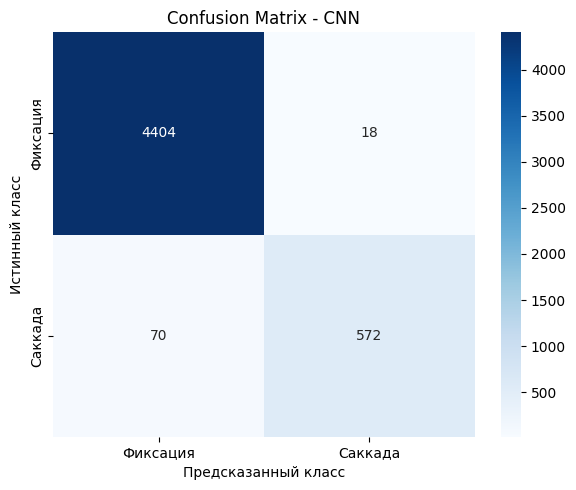

In [ ]:
# 4.1 CNN МОДЕЛЬ
print("\n" + "-" * 40)
print("CNN МОДЕЛЬ")
print("-" * 40)

cnn_model, cnn_history, cnn_scaler = train_cnn_model(X_train_dl, y_train_dl, X_val_dl, y_val_dl)

# Нормализация тестовых данных для CNN
X_test_cnn_norm = cnn_scaler.transform(
    X_test_dl.reshape(-1, X_test_dl.shape[-1])
).reshape(X_test_dl.shape)

# Предсказания CNN
y_pred_cnn_prob = cnn_model.predict(X_test_cnn_norm, verbose=0)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype(int).flatten()
y_pred_cnn = y_pred_cnn + 1  # 0→1, 1→2

# Оценка CNN
cnn_results = evaluate_and_print_metrics(y_test_dl, y_pred_cnn, "CNN")
all_results['CNN'] = cnn_results
all_predictions['CNN'] = y_pred_cnn


----------------------------------------
LSTM МОДЕЛЬ
----------------------------------------
Архитектура LSTM модели:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 20, 128)        │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,305 (321.50 KB)

 Trainable params: 82,305 (321.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
565/565 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - Precision: 0.7404 - Recall: 0.6678 - accuracy: 0.9396 - loss: 0.2049 - val_Precision: 0.8545 - val_Recall: 0.8290 - val_accuracy: 0.9652 - val_loss: 0.1071 - learning_rate: 0.0010
Epoch 2/40
565/565 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - Precision: 0.9004 - Recall: 0.8064 - accuracy: 0.9701 - loss: 0.0929 - val_Precision: 0.8929 - val_Recall: 0.8449 - val_accuracy: 0.9714 - val_loss: 0.0900 - learning_rate: 0.0010
Epoch 3/40
565/565 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - Precision: 0.9111 - Recall: 0.8425 - accuracy: 0.9747 - loss: 0.0775 - val_Precision: 0.9226 - val_Recall: 0.8290 - val_accuracy: 0.9732 - val_loss: 0.0789 - learning_rate: 0.0010
Epoch 4/40
565/565 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step - Precision: 0.9291 - Recall: 0.8555 - accuracy: 0.9780 - loss: 0.0679 - val_Precision: 0.9688 - val_Recall: 0.8032 - val_accuracy: 0.9752 - val_loss: 0.0788 - learning_rate: 0.0010
Epoch 5/40
565/565 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - 

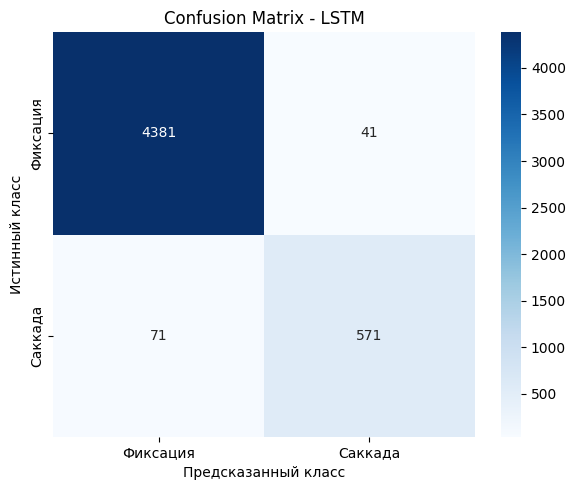

In [ ]:
# 4.2 LSTM МОДЕЛЬ
print("\n" + "-" * 40)
print("LSTM МОДЕЛЬ")
print("-" * 40)

lstm_model, lstm_history, lstm_scaler = train_lstm_model(X_train_dl, y_train_dl, X_val_dl, y_val_dl)

# Нормализация тестовых данных для LSTM
X_test_lstm_norm = lstm_scaler.transform(
    X_test_dl.reshape(-1, X_test_dl.shape[-1])
).reshape(X_test_dl.shape)

# Предсказания LSTM
y_pred_lstm_prob = lstm_model.predict(X_test_lstm_norm, verbose=0)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()
y_pred_lstm = y_pred_lstm + 1

# Оценка LSTM
lstm_results = evaluate_and_print_metrics(y_test_dl, y_pred_lstm, "LSTM")
all_results['LSTM'] = lstm_results
all_predictions['LSTM'] = y_pred_lstm


----------------------------------------
CNN-LSTM ГИБРИДНАЯ МОДЕЛЬ
----------------------------------------

📊 ОЦЕНКА МОДЕЛИ: CNN-LSTM
🎯 РЕЗУЛЬТАТЫ НА ТЕСТЕ:
  Accuracy:  0.9818
  Precision: 0.9479
  Recall:    0.9065
  F1-score:  0.9268

🎯 CONFUSION MATRIX:
  [[4390   32]
   [  60  582]]
  TN (истинные фиксации): 4390
  FP (ложные саккады):    32
  FN (ложные фиксации):   60
  TP (истинные саккады):  582

📋 ДЕТАЛЬНЫЙ ОТЧЕТ:
              precision    recall  f1-score   support

Фиксация (1)     0.9865    0.9928    0.9896      4422
 Саккада (2)     0.9479    0.9065    0.9268       642

    accuracy                         0.9818      5064
   macro avg     0.9672    0.9497    0.9582      5064
weighted avg     0.9816    0.9818    0.9817      5064



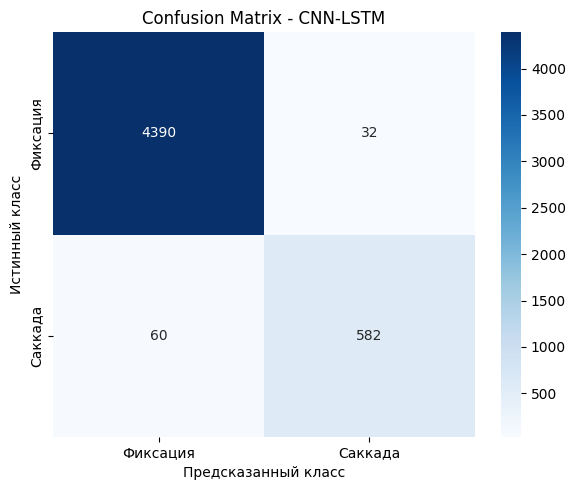

In [ ]:
# 4.3 CNN-LSTM ГИБРИДНАЯ МОДЕЛЬ
print("\n" + "-" * 40)
print("CNN-LSTM ГИБРИДНАЯ МОДЕЛЬ")
print("-" * 40)

try:
    # Подготовка данных
    scaler_cnn_lstm = StandardScaler()
    X_train_cnn_lstm_norm = scaler_cnn_lstm.fit_transform(
        X_train_dl.reshape(-1, X_train_dl.shape[-1])
    ).reshape(X_train_dl.shape)

    X_val_cnn_lstm_norm = scaler_cnn_lstm.transform(
        X_val_dl.reshape(-1, X_val_dl.shape[-1])
    ).reshape(X_val_dl.shape)

    X_test_cnn_lstm_norm = scaler_cnn_lstm.transform(
        X_test_dl.reshape(-1, X_test_dl.shape[-1])
    ).reshape(X_test_dl.shape)

    # Обучение
    cnn_lstm_model = build_cnn_lstm_model((X_train_dl.shape[1], X_train_dl.shape[2]))

    cnn_lstm_model.fit(
        X_train_cnn_lstm_norm, y_train_dl - 1,
        validation_data=(X_val_cnn_lstm_norm, y_val_dl - 1),
        epochs=30,
        batch_size=32,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
        ]
    )

    # Предсказания
    y_pred_cnn_lstm_prob = cnn_lstm_model.predict(X_test_cnn_lstm_norm, verbose=0)
    y_pred_cnn_lstm = (y_pred_cnn_lstm_prob > 0.5).astype(int).flatten()
    y_pred_cnn_lstm = y_pred_cnn_lstm + 1

    # Оценка
    cnn_lstm_results = evaluate_and_print_metrics(y_test_dl, y_pred_cnn_lstm, "CNN-LSTM")
    all_results['CNN-LSTM'] = cnn_lstm_results
    all_predictions['CNN-LSTM'] = y_pred_cnn_lstm

except Exception as e:
    print(f"Ошибка при обучении CNN-LSTM: {e}")


In [ ]:
all_results['CNN'] = cnn_results
all_predictions['CNN'] = y_pred_cnn
all_results['LSTM'] = lstm_results
all_predictions['LSTM'] = y_pred_lstm
all_results['CNN-LSTM'] = cnn_lstm_results
all_predictions['CNN-LSTM'] = y_pred_cnn_lstm

In [ ]:
"""
Улучшенный HMMSegmenter для работы напрямую с DataFrame
"""
class HMMSegmenterDirect:
    """
    Улучшенный HMM сегментатор, работающий напрямую с DataFrame
    """

    def __init__(self, n_components: int = 2, covariance_type: str = 'diag',
                 n_iter: int = 100, min_fixation_duration: float = 0.06,
                 merge_fixations: bool = True, fps: float = 500):
        """
        Инициализация улучшенного сегментатора HMM.
        """
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.n_iter = n_iter
        self.min_fixation_duration = min_fixation_duration
        self.merge_fixations = merge_fixations
        self.fps = fps
        self.model = None

    def prepare_features(self, df: pd.DataFrame, x_col='gaze_x', y_col='gaze_y'):
        """
        Подготавливает признаки для HMM
        """
        df_work = df.copy()

        # Создаем время
        df_work['time'] = np.arange(len(df_work)) / self.fps

        # Сглаживание координат
        if len(df_work) >= 7:
            x_smooth = savgol_filter(df_work[x_col],
                                    window_length=min(7, len(df_work)),
                                    polyorder=2, mode='nearest')
            y_smooth = savgol_filter(df_work[y_col],
                                    window_length=min(7, len(df_work)),
                                    polyorder=2, mode='nearest')
        else:
            x_smooth = df_work[x_col].values
            y_smooth = df_work[y_col].values

        # Вычисление скорости (более устойчивый метод)
        dt = 1 / self.fps

        # Используем gradient вместо diff для более гладкой производной
        dx = np.gradient(x_smooth, dt)
        dy = np.gradient(y_smooth, dt)
        velocity = np.sqrt(dx**2 + dy**2)

        # Дополнительные признаки для HMM
        # 1. Ускорение
        acceleration = np.gradient(velocity, dt)

        # 2. Угол движения
        angles = np.arctan2(dy, dx)

        # 3. Изменение угла (угловая скорость)
        angle_change = np.abs(np.diff(angles, prepend=angles[0]))
        # Обрабатываем переход через 2π
        angle_change = np.minimum(angle_change, 2*np.pi - angle_change)

        # 4. Нормализованная дисперсия в скользящем окне
        window_size = int(0.05 * self.fps)  # 50 мс окно
        if window_size < 3:
            window_size = 3

        x_var = pd.Series(x_smooth).rolling(window=window_size, center=True).std().fillna(0).values
        y_var = pd.Series(y_smooth).rolling(window=window_size, center=True).std().fillna(0).values

        # Логарифмируем для нормализации
        log_velocity = np.log1p(velocity)
        log_acceleration = np.log1p(np.abs(acceleration))

        # Собираем все признаки
        features = np.column_stack([
            log_velocity,           # логарифм скорости
            log_acceleration,       # логарифм ускорения
            angle_change,           # изменение угла
            x_var,                  # дисперсия по X
            y_var,                  # дисперсия по Y
            x_smooth,               # сглаженная координата X
            y_smooth                # сглаженная координата Y
        ])

        # Удаляем строки с NaN/Inf
        features = features[~np.isnan(features).any(axis=1)]
        features = features[~np.isinf(features).any(axis=1)]

        return features, x_smooth, y_smooth, velocity

    def segment_direct(self, df: pd.DataFrame, x_col='gaze_x', y_col='gaze_y'):
        """
        Сегментация напрямую из DataFrame
        """
        try:
            # Подготавливаем признаки
            X, x_smooth, y_smooth, velocity = self.prepare_features(df, x_col, y_col)

            if len(X) < self.n_components * 10:  # Минимальное количество образцов
                print(f"   ВНИМАНИЕ: Слишком мало данных для HMM ({len(X)} образцов)")
                # Возвращаем базовую сегментацию по скорости
                median_vel = np.median(velocity)
                is_fixation = velocity < median_vel
            else:
                # Создаем и обучаем HMM
                self.model = hmm.GaussianHMM(
                    n_components=self.n_components,
                    covariance_type=self.covariance_type,
                    n_iter=self.n_iter,
                    random_state=42,
                    tol=1e-3,
                    min_covar=1e-3
                )

                try:
                    self.model.fit(X)
                    states = self.model.predict(X)

                    # Определяем состояние фиксации (на основе средней скорости)
                    state_velocities = []
                    for i in range(self.n_components):
                        mask = (states == i)
                        if mask.any():
                            state_velocities.append(np.mean(velocity[mask]))
                        else:
                            state_velocities.append(np.inf)

                    fixation_state = np.argmin(state_velocities)

                    # Создаем массив предсказаний для всех точек
                    is_fixation = np.zeros(len(velocity), dtype=bool)
                    is_fixation[:len(states)] = (states == fixation_state)

                except Exception as e:
                    print(f"   Ошибка обучения HMM: {e}")
                    # Fallback на пороговую сегментацию
                    median_vel = np.median(velocity)
                    is_fixation = velocity < median_vel

            # Постобработка: морфологические операции
            from scipy.ndimage import binary_closing, binary_opening
            from scipy.ndimage import generate_binary_structure

            # Заполняем короткие пробелы в фиксациях (до 30 мс)
            max_gap_samples = int(0.03 * self.fps)  # 30 мс
            structure = np.ones(max_gap_samples + 1)
            is_fixation = binary_closing(is_fixation, structure=structure)

            # Удаляем короткие фиксации (менее min_fixation_duration)
            min_fix_samples = int(self.min_fixation_duration * self.fps)
            structure = np.ones(min_fix_samples)
            is_fixation = binary_opening(is_fixation, structure=structure)

            # Объединение близких фиксаций
            if self.merge_fixations:
                diff = np.diff(np.concatenate(([0], is_fixation.astype(int), [0])))
                fixation_starts = np.where(diff == 1)[0]
                fixation_ends = np.where(diff == -1)[0] - 1

                # Объединяем фиксации с небольшими промежутками
                merged_starts = []
                merged_ends = []

                if len(fixation_starts) > 0:
                    current_start = fixation_starts[0]
                    current_end = fixation_ends[0]

                    for i in range(1, len(fixation_starts)):
                        gap = fixation_starts[i] - current_end - 1
                        gap_duration = gap / self.fps

                        if gap_duration <= 0.04:  # Объединяем если промежуток <= 40 мс
                            current_end = fixation_ends[i]
                        else:
                            merged_starts.append(current_start)
                            merged_ends.append(current_end)
                            current_start = fixation_starts[i]
                            current_end = fixation_ends[i]

                    merged_starts.append(current_start)
                    merged_ends.append(current_end)

                    # Обновляем массив фиксаций
                    is_fixation_new = np.zeros(len(is_fixation), dtype=bool)
                    for start_idx, end_idx in zip(merged_starts, merged_ends):
                        is_fixation_new[start_idx:end_idx + 1] = True

                    is_fixation = is_fixation_new

            # Создаем фиксации
            diff = np.diff(np.concatenate(([0], is_fixation.astype(int), [0])))
            fixation_starts = np.where(diff == 1)[0]
            fixation_ends = np.where(diff == -1)[0] - 1

            fixations = []
            for start_idx, end_idx in zip(fixation_starts, fixation_ends):
                duration = (end_idx - start_idx + 1) / self.fps
                if duration >= self.min_fixation_duration:
                    fixations.append({
                        'start_idx': start_idx,
                        'end_idx': end_idx,
                        'start_time': start_idx / self.fps,
                        'end_time': (end_idx + 1) / self.fps,
                        'duration': duration,
                        'x_center': np.mean(x_smooth[start_idx:end_idx + 1]),
                        'y_center': np.mean(y_smooth[start_idx:end_idx + 1]),
                        'mean_velocity': np.mean(velocity[start_idx:end_idx + 1])
                    })

            # Создаем предсказания в формате 1=фиксация, 2=саккада
            y_pred = np.where(is_fixation, 1, 2)

            return {
                'is_fixation': is_fixation,
                'y_pred': y_pred,
                'fixations': pd.DataFrame(fixations) if fixations else pd.DataFrame(),
                'velocity': velocity
            }

        except Exception as e:
            print(f"   Ошибка в HMMSegmenterDirect: {e}")
            # Возвращаем базовые предсказания
            y_pred = np.ones(len(df), dtype=int)  # Все фиксации по умолчанию
            return {
                'is_fixation': np.ones(len(df), dtype=bool),
                'y_pred': y_pred,
                'fixations': pd.DataFrame(),
                'velocity': np.zeros(len(df))
            }


class MultiStateHMMSegmenter:
    """
    HMM сегментатор с несколькими состояниями для лучшей детекции
    """

    def __init__(self, n_components: int = 3, min_fixation_duration: float = 0.06, fps: float = 500):
        """
        HMM с 3 состояниями: фиксация, медленная саккада, быстрая саккада
        """
        self.n_components = n_components
        self.min_fixation_duration = min_fixation_duration
        self.fps = fps
        self.model = None

    def segment_direct(self, df: pd.DataFrame, x_col='gaze_x', y_col='gaze_y'):
        """
        Сегментация с несколькими состояниями
        """
        try:
            # Подготавливаем данные
            df_work = df.copy()
            df_work['time'] = np.arange(len(df_work)) / self.fps

            # Сглаживание
            if len(df_work) >= 7:
                x_smooth = savgol_filter(df_work[x_col],
                                        window_length=min(7, len(df_work)),
                                        polyorder=2)
                y_smooth = savgol_filter(df_work[y_col],
                                        window_length=min(7, len(df_work)),
                                        polyorder=2)
            else:
                x_smooth = df_work[x_col].values
                y_smooth = df_work[y_col].values

            # Вычисление скорости и ускорения
            dt = 1 / self.fps
            dx = np.gradient(x_smooth, dt)
            dy = np.gradient(y_smooth, dt)
            velocity = np.sqrt(dx**2 + dy**2)
            acceleration = np.gradient(velocity, dt)

            # Признаки для HMM
            features = np.column_stack([
                np.log1p(velocity),          # Логарифм скорости
                np.log1p(np.abs(acceleration)),  # Логарифм ускорения
                np.abs(dx),                   # Абсолютное изменение по X
                np.abs(dy),                   # Абсолютное изменение по Y
                x_smooth,                     # Координата X
                y_smooth                      # Координата Y
            ])

            # Удаляем NaN/Inf
            features = features[~np.isnan(features).any(axis=1)]
            features = features[~np.isinf(features).any(axis=1)]

            if len(features) < self.n_components * 10:
                # Fallback на простую сегментацию
                median_vel = np.median(velocity)
                is_fixation = velocity < median_vel
            else:
                # Обучаем HMM
                self.model = hmm.GaussianHMM(
                    n_components=self.n_components,
                    covariance_type='diag',
                    n_iter=200,
                    random_state=42
                )
                self.model.fit(features)
                states = self.model.predict(features)

                # Определяем состояния по средней скорости
                state_stats = []
                for i in range(self.n_components):
                    mask = (states == i)
                    if mask.any():
                        mean_vel = np.mean(velocity[mask])
                        std_vel = np.std(velocity[mask])
                        state_stats.append({
                            'state': i,
                            'mean_velocity': mean_vel,
                            'std_velocity': std_vel,
                            'count': mask.sum()
                        })
                    else:
                        state_stats.append({
                            'state': i,
                            'mean_velocity': np.inf,
                            'std_velocity': 0,
                            'count': 0
                        })

                # Сортируем по средней скорости
                state_stats.sort(key=lambda x: x['mean_velocity'])

                # Самое медленное состояние - фиксация
                fixation_state = state_stats[0]['state']

                # Создаем предсказания
                is_fixation_full = np.zeros(len(velocity), dtype=bool)
                is_fixation_full[:len(states)] = (states == fixation_state)
                is_fixation = is_fixation_full

            # Постобработка
            from scipy.ndimage import binary_closing, binary_opening

            # Заполняем короткие пробелы
            max_gap_samples = int(0.025 * self.fps)
            structure = np.ones(max_gap_samples + 1)
            is_fixation = binary_closing(is_fixation, structure=structure)

            # Удаляем короткие фиксации
            min_fix_samples = int(self.min_fixation_duration * self.fps)
            structure = np.ones(min_fix_samples)
            is_fixation = binary_opening(is_fixation, structure=structure)

            # Создаем предсказания
            y_pred = np.where(is_fixation, 1, 2)

            return {
                'is_fixation': is_fixation,
                'y_pred': y_pred,
                'velocity': velocity
            }

        except Exception as e:
            print(f"   Ошибка в MultiStateHMMSegmenter: {e}")
            y_pred = np.ones(len(df), dtype=int)
            return {
                'is_fixation': np.ones(len(df), dtype=bool),
                'y_pred': y_pred,
                'velocity': np.zeros(len(df))
            }


# Тестируем HMM алгоритмы
print("\n" + "="*80)
print("ТЕСТИРОВАНИЕ HMM АЛГОРИТМОВ СЕГМЕНТАЦИИ")
print("="*80)

hmm_algorithms = {
    'HMM Basic (2 states)': HMMSegmenterDirect(n_components=2, n_iter=100, min_fixation_duration=0.06, fps=500),
    'HMM Advanced (3 states)': HMMSegmenterDirect(n_components=3, n_iter=150, min_fixation_duration=0.06, fps=500),
    'HMM Conservative (2 states)': HMMSegmenterDirect(n_components=2, n_iter=200, min_fixation_duration=0.08, fps=500),
    'Multi-State HMM (3 states)': MultiStateHMMSegmenter(n_components=3, min_fixation_duration=0.06, fps=500),
    'Multi-State HMM (4 states)': MultiStateHMMSegmenter(n_components=4, min_fixation_duration=0.06, fps=500),
}

hmm_results = {}
hmm_predictions = {}

for algo_name, segmenter in hmm_algorithms.items():
    print(f"\n{'─'*60}")
    print(f"HMM АЛГОРИТМ: {algo_name}")
    print(f"{'─'*60}")

    try:
        print("   Запуск алгоритма...")
        results = segmenter.segment_direct(df_test_filtered, x_col='gaze_x', y_col='gaze_y')

        # Получаем предсказания
        y_pred = results['y_pred']

        print("   Вычисление метрик...")
        metrics = evaluate_segmentation_predictions(y_test_filtered, y_pred, algo_name)

        hmm_results[algo_name] = metrics
        hmm_predictions[algo_name] = y_pred

        print(f"   ✓ Успешно протестирован: F1={metrics['f1']:.4f}, Acc={metrics['accuracy']:.4f}")

    except Exception as e:
        print(f"   ✗ Ошибка: {e}")
        import traceback
        traceback.print_exc()

# Добавляем HMM результаты
if hmm_results:
    for algo_name, results in hmm_results.items():
        new_name = f"HMM: {algo_name}"
        all_results[new_name] = results
        all_predictions[new_name] = hmm_predictions[algo_name]

    print(f"\n✓ Добавлено {len(hmm_results)} HMM алгоритмов")

    print("\nТОП-3 ЛУЧШИХ HMM АЛГОРИТМА:")
    sorted_hmm = sorted(hmm_results.items(), key=lambda x: x[1]['f1'], reverse=True)
    for i, (algo_name, results) in enumerate(sorted_hmm[:3], 1):
        print(f"  {i}. {algo_name}: F1={results['f1']:.4f}, Acc={results['accuracy']:.4f}, "
              f"Predicted Fixations: {results['fixations_pred']/len(y_test_filtered)*100:.1f}%")


ТЕСТИРОВАНИЕ HMM АЛГОРИТМОВ СЕГМЕНТАЦИИ

────────────────────────────────────────────────────────────
HMM АЛГОРИТМ: HMM Basic (2 states)
────────────────────────────────────────────────────────────
   Запуск алгоритма...
   Вычисление метрик...

   РЕЗУЛЬТАТЫ HMM Basic (2 states):
     Accuracy:  0.8363
     Precision: 0.4350
     Recall:    0.9966
     F1-score:  0.6057
     Confusion Matrix: TN=18166, FP=4175, FN=11, TP=3215
     Предсказано: 18177 фиксаций (71.1%), 7390 саккад (28.9%)
     Истинных:   22341 фиксаций (87.4%), 3226 саккад (12.6%)
   ✓ Успешно протестирован: F1=0.6057, Acc=0.8363

────────────────────────────────────────────────────────────
HMM АЛГОРИТМ: HMM Advanced (3 states)
────────────────────────────────────────────────────────────
   Запуск алгоритма...
   Вычисление метрик...

   РЕЗУЛЬТАТЫ HMM Advanced (3 states):
     Accuracy:  0.5627
     Precision: 0.2239
     Recall:    1.0000
     F1-score:  0.3659
     Confusion Matrix: TN=11161, FP=11180, FN=0, TP=322

In [ ]:
class ImprovedIVTSegmenter:
    """
    Улучшенный I-VT сегментатор с постобработкой
    """

    def __init__(self, velocity_threshold: float = 20, min_fixation_duration: float = 0.06,
                 merge_close_fixations: bool = True, max_gap_between_fixations: float = 0.05,
                 fps: float = 500):
        self.velocity_threshold = velocity_threshold  # Меньший порог для более чувствительной детекции
        self.min_fixation_duration = min_fixation_duration  # Более короткие фиксации
        self.merge_close_fixations = merge_close_fixations
        self.max_gap_between_fixations = max_gap_between_fixations
        self.fps = fps

    def segment_direct(self, df: pd.DataFrame, x_col='gaze_x', y_col='gaze_y'):
        """
        Улучшенная сегментация с постобработкой
        """
        df_work = df.copy()

        # Добавляем время
        df_work['time'] = np.arange(len(df_work)) / self.fps

        # Сглаживание
        if len(df_work) >= 7:
            x_smooth = savgol_filter(df_work[x_col], window_length=min(7, len(df_work)), polyorder=2, mode='nearest')
            y_smooth = savgol_filter(df_work[y_col], window_length=min(7, len(df_work)), polyorder=2, mode='nearest')
        else:
            x_smooth = df_work[x_col].values
            y_smooth = df_work[y_col].values

        # Вычисление скорости с дополнительным сглаживанием
        dt = 1 / self.fps
        dx = np.gradient(x_smooth, dt)
        dy = np.gradient(y_smooth, dt)
        velocity = np.sqrt(dx**2 + dy**2)

        # Нормализация скорости (относительно медианы)
        velocity_median = np.median(velocity)
        velocity_normalized = velocity / (velocity_median + 1e-10)

        # Адаптивный порог на основе квантилей
        threshold_multiplier = 1.5  # Можно настроить
        adaptive_threshold = np.percentile(velocity_normalized, 75) * threshold_multiplier

        # Определение фиксаций
        is_fixation = velocity_normalized < adaptive_threshold

        # Постобработка: удаление коротких саккад внутри фиксаций
        min_saccade_duration = 0.02  # 20 мс
        min_saccade_samples = int(min_saccade_duration * self.fps)

        # Находим группы фиксаций
        fixation_groups = []
        current_group = None

        for i in range(len(is_fixation)):
            if is_fixation[i]:
                if current_group is None:
                    current_group = {'start': i, 'end': i}
                else:
                    current_group['end'] = i
            else:
                if current_group is not None:
                    fixation_groups.append((current_group['start'], current_group['end']))
                    current_group = None

        if current_group is not None:
            fixation_groups.append((current_group['start'], current_group['end']))

        # Объединение близких фиксаций
        if self.merge_close_fixations and len(fixation_groups) > 1:
            merged_groups = []
            current_start, current_end = fixation_groups[0]

            for i in range(1, len(fixation_groups)):
                next_start, next_end = fixation_groups[i]
                gap = (next_start - current_end) / self.fps

                if gap <= self.max_gap_between_fixations:
                    # Объединяем фиксации
                    current_end = next_end
                else:
                    merged_groups.append((current_start, current_end))
                    current_start, current_end = next_start, next_end

            merged_groups.append((current_start, current_end))
            fixation_groups = merged_groups

        # Создаем фиксации
        fixations = []
        for start_idx, end_idx in fixation_groups:
            duration = (end_idx - start_idx + 1) / self.fps
            if duration >= self.min_fixation_duration:
                fixations.append({
                    'start_idx': start_idx,
                    'end_idx': end_idx,
                    'start_time': start_idx / self.fps,
                    'end_time': (end_idx + 1) / self.fps,
                    'duration': duration,
                    'x_center': np.mean(x_smooth[start_idx:end_idx + 1]),
                    'y_center': np.mean(y_smooth[start_idx:end_idx + 1]),
                    'amplitude': 0
                })

        # Создаем саккады между фиксациями
        saccades = []
        for i in range(1, len(fixations)):
            prev_fix = fixations[i - 1]
            curr_fix = fixations[i]

            # Проверяем, что между фиксациями есть промежуток
            if curr_fix['start_idx'] > prev_fix['end_idx'] + 1:
                saccades.append({
                    'start_idx': prev_fix['end_idx'] + 1,
                    'end_idx': curr_fix['start_idx'] - 1,
                    'start_time': (prev_fix['end_idx'] + 1) / self.fps,
                    'end_time': (curr_fix['start_idx'] - 1) / self.fps,
                    'duration': (curr_fix['start_idx'] - prev_fix['end_idx'] - 1) / self.fps,
                    'start_x': x_smooth[prev_fix['end_idx']],
                    'start_y': y_smooth[prev_fix['end_idx']],
                    'end_x': x_smooth[curr_fix['start_idx']],
                    'end_y': y_smooth[curr_fix['start_idx']],
                    'amplitude': np.sqrt((x_smooth[curr_fix['start_idx']] - x_smooth[prev_fix['end_idx']])**2 +
                                       (y_smooth[curr_fix['start_idx']] - y_smooth[prev_fix['end_idx']])**2)
                })

        # Создаем предсказания для каждого кадра
        is_fixation_final = np.zeros(len(df_work), dtype=bool)
        for fix in fixations:
            start_idx = fix['start_idx']
            end_idx = fix['end_idx']
            is_fixation_final[start_idx:end_idx + 1] = True

        return {
            'fixations': pd.DataFrame(fixations) if fixations else pd.DataFrame(),
            'saccades': pd.DataFrame(saccades) if saccades else pd.DataFrame(),
            'is_fixation': is_fixation_final
        }


class AdaptiveThresholdSegmenter:
    """
    Сегментатор с адаптивными порогами
    """

    def __init__(self, base_velocity_threshold=50, min_fixation_duration=0.08, fps=500):
        self.base_velocity_threshold = base_velocity_threshold
        self.min_fixation_duration = min_fixation_duration
        self.fps = fps

    def segment_direct(self, df: pd.DataFrame, x_col='gaze_x', y_col='gaze_y'):
        df_work = df.copy()
        df_work['time'] = np.arange(len(df_work)) / self.fps

        # Сглаживание
        if len(df_work) >= 5:
            x_smooth = savgol_filter(df_work[x_col], window_length=min(5, len(df_work)), polyorder=2)
            y_smooth = savgol_filter(df_work[y_col], window_length=min(5, len(df_work)), polyorder=2)
        else:
            x_smooth = df_work[x_col].values
            y_smooth = df_work[y_col].values

        # Вычисление скорости
        dt = 1 / self.fps
        dx = np.diff(x_smooth, prepend=x_smooth[0])
        dy = np.diff(y_smooth, prepend=y_smooth[0])
        velocity = np.sqrt(dx**2 + dy**2) / dt

        # Адаптивный порог: медиана + 2*MAD
        median_vel = np.median(velocity)
        mad_vel = np.median(np.abs(velocity - median_vel))
        adaptive_threshold = median_vel + 2 * mad_vel

        # Можно использовать комбинацию фиксированного и адаптивного порога
        final_threshold = min(self.base_velocity_threshold, adaptive_threshold)

        # Определение фиксаций
        is_fixation = velocity < final_threshold

        # Постобработка: морфологическое закрытие (заполнение коротких пробелов)
        from scipy.ndimage import binary_closing, binary_opening

        # Преобразуем в массив для морфологических операций
        fixation_mask = is_fixation.astype(bool)

        # Заполняем короткие пробелы (до 25 мс)
        max_gap_samples = int(0.025 * self.fps)  # 25 мс
        structure = np.ones(max_gap_samples + 1)
        fixation_mask = binary_closing(fixation_mask, structure=structure)

        # Удаляем короткие фиксации (менее min_fixation_duration)
        min_fix_samples = int(self.min_fixation_duration * self.fps)
        structure = np.ones(min_fix_samples)
        fixation_mask = binary_opening(fixation_mask, structure=structure)

        # Находим группы фиксаций
        diff = np.diff(np.concatenate(([0], fixation_mask.astype(int), [0])))
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0] - 1

        fixations = []
        for start_idx, end_idx in zip(starts, ends):
            duration = (end_idx - start_idx + 1) / self.fps
            if duration >= self.min_fixation_duration:
                fixations.append({
                    'start_idx': start_idx,
                    'end_idx': end_idx,
                    'start_time': start_idx / self.fps,
                    'end_time': (end_idx + 1) / self.fps,
                    'duration': duration,
                    'x_center': np.mean(x_smooth[start_idx:end_idx + 1]),
                    'y_center': np.mean(y_smooth[start_idx:end_idx + 1])
                })

        # Создаем предсказания
        is_fixation_final = np.zeros(len(df_work), dtype=bool)
        for fix in fixations:
            is_fixation_final[fix['start_idx']:fix['end_idx'] + 1] = True

        return {
            'is_fixation': is_fixation_final,
            'fixations': pd.DataFrame(fixations) if fixations else pd.DataFrame()
        }


# Тестируем улучшенные алгоритмы
print("\n" + "="*80)
print("ТЕСТИРОВАНИЕ УЛУЧШЕННЫХ АЛГОРИТМОВ СЕГМЕНТАЦИИ")
print("="*80)

improved_algorithms = {
    'Improved I-VT (adaptive)': ImprovedIVTSegmenter(velocity_threshold=20, min_fixation_duration=0.06),
    'Adaptive Threshold': AdaptiveThresholdSegmenter(base_velocity_threshold=30, min_fixation_duration=0.08),
    'I-VT Conservative (v=10)': IVTSegmenterDirect(velocity_threshold=10, min_fixation_duration=0.05, fps=500),
    'I-VT Conservative (v=15)': IVTSegmenterDirect(velocity_threshold=15, min_fixation_duration=0.05, fps=500),
    'I-DT Conservative (d=40)': IDTSegmenterDirect(dispersion_threshold=40, window_duration=0.15,
                                                  min_fixation_duration=0.05, fps=500),
    'I-DT Conservative (d=50)': IDTSegmenterDirect(dispersion_threshold=50, window_duration=0.15,
                                                  min_fixation_duration=0.05, fps=500),
}

improved_results = {}
improved_predictions = {}

for algo_name, segmenter in improved_algorithms.items():
    print(f"\n{'─'*60}")
    print(f"УЛУЧШЕННЫЙ АЛГОРИТМ: {algo_name}")
    print(f"{'─'*60}")

    try:
        print("   Запуск алгоритма...")
        results = segmenter.segment_direct(df_test_filtered, x_col='gaze_x', y_col='gaze_y')

        # Получаем предсказания
        is_fixation = results['is_fixation']
        y_pred = np.where(is_fixation, 1, 2)

        print("   Вычисление метрик...")
        metrics = evaluate_segmentation_predictions(y_test_filtered, y_pred, algo_name)

        improved_results[algo_name] = metrics
        improved_predictions[algo_name] = y_pred

        print(f"   ✓ Успешно протестирован: F1={metrics['f1']:.4f}, Acc={metrics['accuracy']:.4f}")

    except Exception as e:
        print(f"   ✗ Ошибка: {e}")
        import traceback
        traceback.print_exc()

# Добавляем улучшенные результаты
if improved_results:
    for algo_name, results in improved_results.items():
        new_name = f"Improved: {algo_name}"
        all_results[new_name] = results
        all_predictions[new_name] = improved_predictions[algo_name]

    print(f"\n✓ Добавлено {len(improved_results)} улучшенных алгоритмов")

    print("\nТОП-5 ЛУЧШИХ АЛГОРИТМОВ СЕГМЕНТАЦИИ:")
    all_segmentation_results = {**segmentation_results, **improved_results}
    sorted_algorithms = sorted(all_segmentation_results.items(),
                               key=lambda x: x[1]['f1'],
                               reverse=True)
    for i, (algo_name, results) in enumerate(sorted_algorithms[:5], 1):
        print(f"  {i}. {algo_name}: F1={results['f1']:.4f}, Acc={results['accuracy']:.4f}, "
              f"Predicted Fixations: {results['fixations_pred']/len(y_test_filtered)*100:.1f}%")


ТЕСТИРОВАНИЕ УЛУЧШЕННЫХ АЛГОРИТМОВ СЕГМЕНТАЦИИ

────────────────────────────────────────────────────────────
УЛУЧШЕННЫЙ АЛГОРИТМ: Improved I-VT (adaptive)
────────────────────────────────────────────────────────────
   Запуск алгоритма...
   Вычисление метрик...

   РЕЗУЛЬТАТЫ Improved I-VT (adaptive):
     Accuracy:  0.9142
     Precision: 0.9025
     Recall:    0.3586
     F1-score:  0.5133
     Confusion Matrix: TN=22216, FP=125, FN=2069, TP=1157
     Предсказано: 24285 фиксаций (95.0%), 1282 саккад (5.0%)
     Истинных:   22341 фиксаций (87.4%), 3226 саккад (12.6%)
   ✓ Успешно протестирован: F1=0.5133, Acc=0.9142

────────────────────────────────────────────────────────────
УЛУЧШЕННЫЙ АЛГОРИТМ: Adaptive Threshold
────────────────────────────────────────────────────────────
   Запуск алгоритма...
   Вычисление метрик...

   РЕЗУЛЬТАТЫ Adaptive Threshold:
     Accuracy:  0.1262
     Precision: 0.1262
     Recall:    1.0000
     F1-score:  0.2241
     Confusion Matrix: TN=0, FP=2234


6. ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по F1-Score):
  Модель  Accuracy  Precision  Recall  F1-Score  Всего
     CNN    0.9826     0.9695  0.8910    0.9286   5064
CNN-LSTM    0.9818     0.9479  0.9065    0.9268   5064
    LSTM    0.9779     0.9330  0.8894    0.9107   5064

MATRIЦЫ ОШИБОК ДЛЯ ВСЕХ МОДЕЛЕЙ:

CNN             | TN:  4404 | FP:   18 | FN:   70 | TP:  572

LSTM            | TN:  4381 | FP:   41 | FN:   71 | TP:  571

CNN-LSTM        | TN:  4390 | FP:   32 | FN:   60 | TP:  582

ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ...


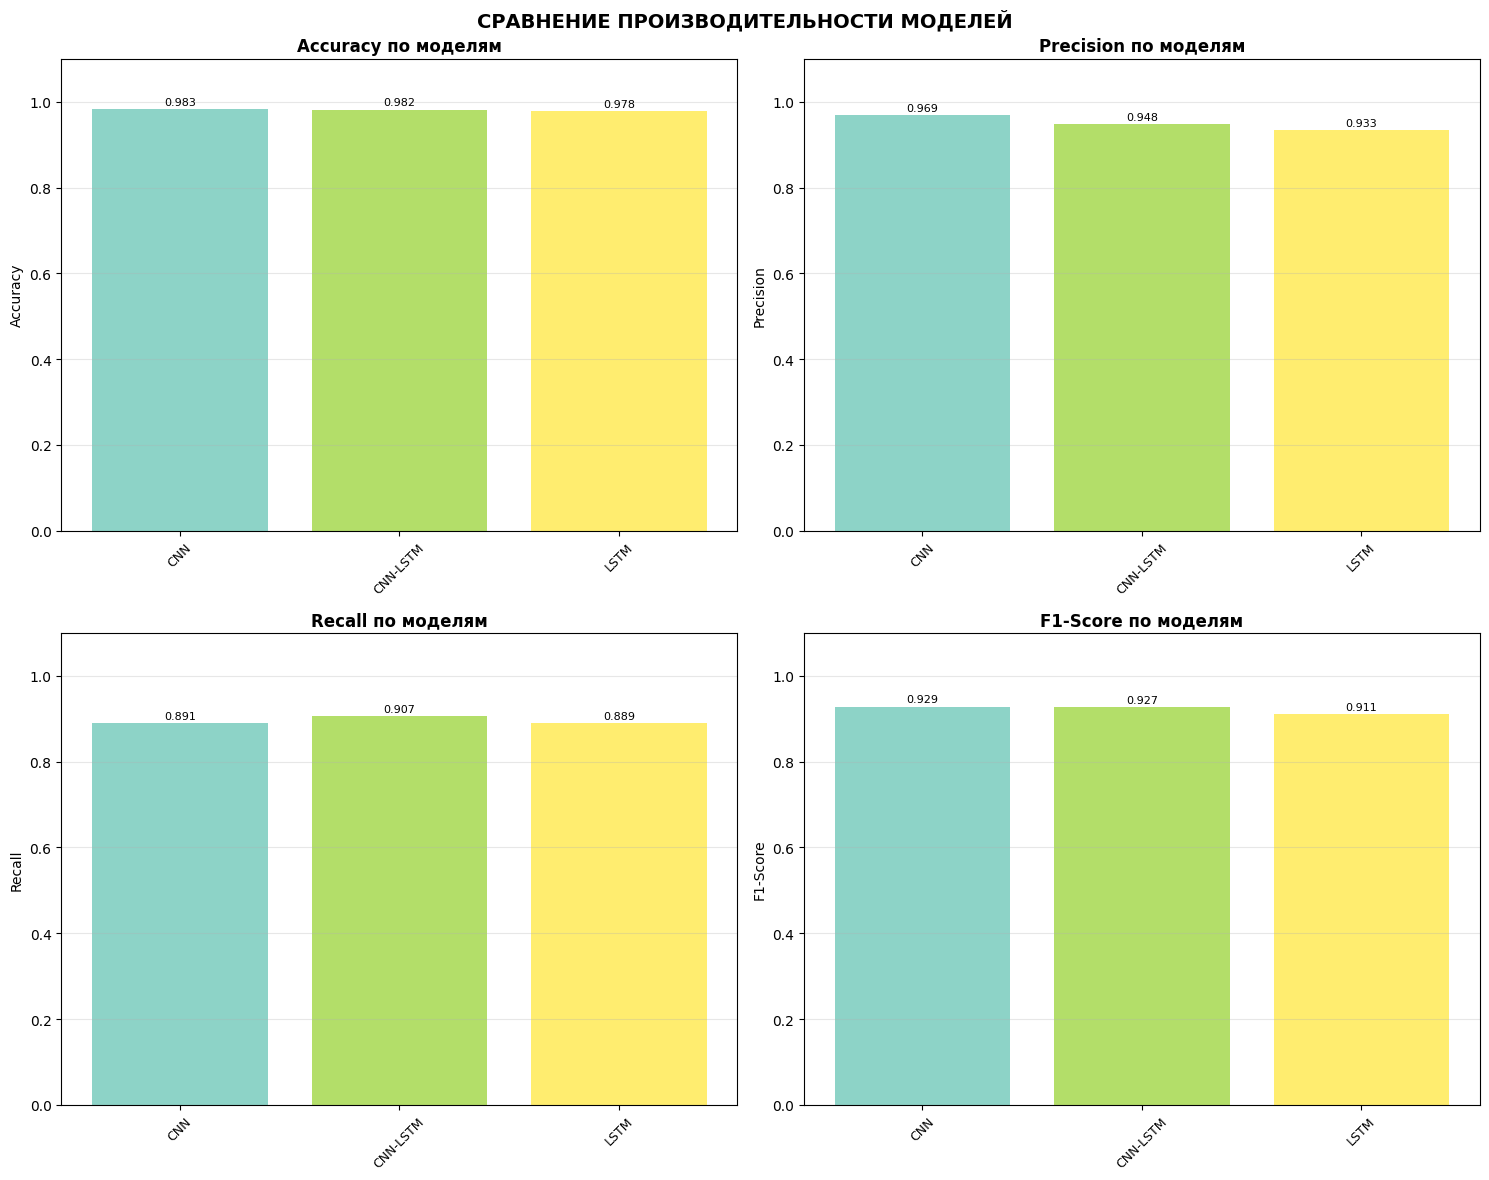


ЛУЧШИЕ МОДЕЛИ ПО КАЖДОЙ МЕТРИКЕ:
--------------------------------------------------
Accuracy     → CNN             : 0.9826
Precision    → CNN             : 0.9695
Recall       → CNN-LSTM        : 0.9065
F1-Score     → CNN             : 0.9286

ЛУЧШАЯ МОДЕЛЬ В ЦЕЛОМ: CNN
   F1-Score: 0.9286
   Accuracy: 0.9826
   Precision: 0.9695
   Recall: 0.8910

АНАЛИЗ ОШИБОК:
--------------------------------------------------

CNN            :
  Ложные саккады (FP): 18 (0.41%)
  Ложные фиксации (FN): 70 (10.90%)

LSTM           :
  Ложные саккады (FP): 41 (0.93%)
  Ложные фиксации (FN): 71 (11.06%)

CNN-LSTM       :
  Ложные саккады (FP): 32 (0.72%)
  Ложные фиксации (FN): 60 (9.35%)

СОХРАНЕНИЕ РЕЗУЛЬТАТОВ...
Таблица сравнения сохранена: model_comparison_results.csv
Лучшая модель (CNN) сохранена

СОХРАНЕНИЕ ПРЕДСКАЗАНИЙ ВСЕХ МОДЕЛЕЙ...
  CNN                 : 5,064 предсказаний
  LSTM                : 5,064 предсказаний
  CNN-LSTM            : 5,064 предсказаний

Минимальная длина предсказаний: 

In [ ]:
# 6. ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ
print("\n" + "=" * 80)
print("6. ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 80)

if all_results:
    # Создаем DataFrame с результатами
    comparison_data = []
    for model_name, results in all_results.items():
        comparison_data.append({
            'Модель': model_name,
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1-Score': results['f1'],
            'TN': results['tn'],
            'FP': results['fp'],
            'FN': results['fn'],
            'TP': results['tp'],
            'Всего': results['tn'] + results['fp'] + results['fn'] + results['tp']
        })

    comparison_df = pd.DataFrame(comparison_data)

    # Сортируем по F1-Score
    comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

    # Выводим красивую таблицу
    print("\nТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по F1-Score):")
    print("=" * 120)

    # Форматируем вывод
    pd.set_option('display.float_format', lambda x: f'{x:.4f}')
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 120)

    print(comparison_df[['Модель', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Всего']].to_string(index=False))

    # Выводим матрицы ошибок для всех моделей
    print("\nMATRIЦЫ ОШИБОК ДЛЯ ВСЕХ МОДЕЛЕЙ:")
    print("=" * 120)

    for model_name, results in all_results.items():
        cm = results['confusion_matrix']
        print(f"\n{model_name:15} | TN: {cm[0,0]:5} | FP: {cm[0,1]:4} | FN: {cm[1,0]:4} | TP: {cm[1,1]:4}")

    # Визуализация сравнения
    print("\nВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = plt.cm.Set3(np.linspace(0, 1, len(comparison_df)))

    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx//2, idx%2]

        bars = ax.bar(comparison_df['Модель'], comparison_df[metric], color=colors)
        ax.set_title(f'{metric} по моделям', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric, fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.grid(True, alpha=0.3, axis='y')

        # Добавляем значения на столбцы
        for bar, value in zip(bars, comparison_df[metric]):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=8)

        # Устанавливаем лимит оси Y
        ax.set_ylim([0, 1.1])

    plt.suptitle('СРАВНЕНИЕ ПРОИЗВОДИТЕЛЬНОСТИ МОДЕЛЕЙ', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Лучшая модель по каждой метрике
    print("\nЛУЧШИЕ МОДЕЛИ ПО КАЖДОЙ МЕТРИКЕ:")
    print("-" * 50)

    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        best_model = comparison_df.loc[comparison_df[metric].idxmax(), 'Модель']
        best_score = comparison_df[metric].max()
        print(f"{metric:12} → {best_model:15} : {best_score:.4f}")

    # Общая лучшая модель (по F1-Score)
    best_overall = comparison_df.iloc[0]
    print(f"\nЛУЧШАЯ МОДЕЛЬ В ЦЕЛОМ: {best_overall['Модель']}")
    print(f"   F1-Score: {best_overall['F1-Score']:.4f}")
    print(f"   Accuracy: {best_overall['Accuracy']:.4f}")
    print(f"   Precision: {best_overall['Precision']:.4f}")
    print(f"   Recall: {best_overall['Recall']:.4f}")

    # Анализ матриц ошибок
    print("\nАНАЛИЗ ОШИБОК:")
    print("-" * 50)

    for model_name, results in all_results.items():
        fp_rate = results['fp'] / (results['tn'] + results['fp']) if (results['tn'] + results['fp']) > 0 else 0
        fn_rate = results['fn'] / (results['fn'] + results['tp']) if (results['fn'] + results['tp']) > 0 else 0

        print(f"\n{model_name:15}:")
        print(f"  Ложные саккады (FP): {results['fp']} ({fp_rate:.2%})")
        print(f"  Ложные фиксации (FN): {results['fn']} ({fn_rate:.2%})")

    # Исправленный блок сохранения предсказаний
print("\nСОХРАНЕНИЕ РЕЗУЛЬТАТОВ...")

# Сохраняем таблицу сравнения
comparison_df.to_csv('model_comparison_results.csv', index=False, encoding='utf-8-sig')
print(f"Таблица сравнения сохранена: model_comparison_results.csv")

# Сохраняем лучшую модель
best_model_name = best_overall['Модель']
if best_model_name in ['CNN', 'LSTM', 'CNN-LSTM']:
    # Сохраняем DL модель
    if best_model_name == 'CNN':
        cnn_model.save('best_model_cnn.h5')
    elif best_model_name == 'LSTM':
        lstm_model.save('best_model_lstm.h5')
    print(f"Лучшая модель ({best_model_name}) сохранена")

# Сохраняем все предсказания с проверкой длины
print("\nСОХРАНЕНИЕ ПРЕДСКАЗАНИЙ ВСЕХ МОДЕЛЕЙ...")

# Проверяем длины всех массивов предсказаний
prediction_lengths = {}
for model_name, preds in all_predictions.items():
    prediction_lengths[model_name] = len(preds)
    print(f"  {model_name:20}: {len(preds):,} предсказаний")

# Находим минимальную длину для выравнивания
min_length = min(prediction_lengths.values())
print(f"\nМинимальная длина предсказаний: {min_length}")

# Создаем DataFrame с выровненными предсказаниями
predictions_data = {}
for model_name, preds in all_predictions.items():
    # Обрезаем до минимальной длины
    predictions_data[model_name] = preds[:min_length]

predictions_df = pd.DataFrame(predictions_data)

# Добавляем истинные метки (также обрезаем до минимальной длины)
if 'y_test_dl' in locals():
    predictions_df['y_true'] = y_test_dl[:min_length]
elif 'y_test_filtered' in locals():
    predictions_df['y_true'] = y_test_filtered[:min_length]
else:
    print("Внимание: истинные метки не найдены!")

predictions_df.to_csv('all_model_predictions.csv', index=False)
print(f"Предсказания всех моделей сохранены: all_model_predictions.csv")
print(f"  Всего сохранено: {len(predictions_df):,} строк, {len(predictions_df.columns):,} столбцов")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
import warnings
warnings.filterwarnings('ignore')

def balance_dataset(X, y, method='undersample', random_state=42):
    """
    Балансирует датасет выбранным методом

    Параметры:
    -----------
    X : массив признаков
    y : массив меток (1 - фиксации, 2 - саккады)
    method : str, метод балансировки
        - 'undersample': случайный недосэмплинг
        - 'oversample': SMOTE
        - 'adasyn': ADASYN
        - 'smote_tomek': SMOTE + Tomek Links
        - 'smote_enn': SMOTE + ENN
        - 'tomek': Tomek Links (чистка)

    Возвращает:
    -----------
    X_balanced, y_balanced : сбалансированные данные
    """

    # Преобразуем в бинарный формат для библиотеки imblearn
    y_binary = y.copy()
    y_binary[y_binary == 1] = 0  # Фиксации -> 0
    y_binary[y_binary == 2] = 1  # Саккады -> 1

    print(f"   До балансировки:")
    print(f"     Фиксации (0): {(y_binary == 0).sum():,} ({(y_binary == 0).sum()/len(y_binary)*100:.1f}%)")
    print(f"     Саккады (1):  {(y_binary == 1).sum():,} ({(y_binary == 1).sum()/len(y_binary)*100:.1f}%)")

    if method == 'undersample':
        # Случайный недосэмплинг - берем столько же фиксаций, сколько саккад
        sampler = RandomUnderSampler(sampling_strategy='auto', random_state=random_state)
        X_balanced, y_balanced = sampler.fit_resample(X, y_binary)

    elif method == 'oversample':
        # SMOTE - создает синтетические саккады
        sampler = SMOTE(sampling_strategy='auto', random_state=random_state)
        X_balanced, y_balanced = sampler.fit_resample(X, y_binary)

    elif method == 'adasyn':
        # ADASYN - адаптивный SMOTE
        sampler = ADASYN(sampling_strategy='auto', random_state=random_state)
        X_balanced, y_balanced = sampler.fit_resample(X, y_binary)

    elif method == 'smote_tomek':
        # SMOTE + очистка Tomek Links
        sampler = SMOTETomek(sampling_strategy='auto', random_state=random_state)
        X_balanced, y_balanced = sampler.fit_resample(X, y_binary)

    elif method == 'smote_enn':
        # SMOTE + Edited Nearest Neighbours
        sampler = SMOTEENN(sampling_strategy='auto', random_state=random_state)
        X_balanced, y_balanced = sampler.fit_resample(X, y_binary)

    elif method == 'tomek':
        # Только очистка Tomek Links (удаляет "шумные" примеры)
        sampler = TomekLinks(sampling_strategy='auto')
        X_balanced, y_balanced = sampler.fit_resample(X, y_binary)

    else:
        raise ValueError(f"Неизвестный метод балансировки: {method}")

    print(f"   После балансировки ({method}):")
    print(f"     Фиксации (0): {(y_balanced == 0).sum():,} ({(y_balanced == 0).sum()/len(y_balanced)*100:.1f}%)")
    print(f"     Саккады (1):  {(y_balanced == 1).sum():,} ({(y_balanced == 1).sum()/len(y_balanced)*100:.1f}%)")
    print(f"     Всего образцов: {len(X_balanced):,}")

    return X_balanced, y_balanced


def train_classical_models_balanced(X_train, y_train, balance_method='undersample'):
    """
    Обучает классические ML модели на сбалансированном датасете

    Параметры:
    -----------
    X_train : признаки для обучения
    y_train : метки для обучения (1 - фиксации, 2 - саккады)
    balance_method : метод балансировки данных

    Возвращает:
    -----------
    trained_models : словарь обученных моделей
    """

    print(f"\n{'='*80}")
    print(f"ОБУЧЕНИЕ КЛАССИЧЕСКИХ ML МОДЕЛЕЙ")
    print(f"Метод балансировки: {balance_method.upper()}")
    print(f"{'='*80}")

    # Фильтруем только фиксации и саккады (игнорируем другие классы если есть)
    mask = (y_train == 1) | (y_train == 2)

    if hasattr(X_train, 'iloc'):
        X_train_filtered = X_train.iloc[mask]
    else:
        X_train_filtered = X_train[mask]

    y_train_filtered = y_train[mask]

    print(f"\nБАЛАНС КЛАССОВ В ДАННЫХ:")
    fix_count = (y_train_filtered == 1).sum()
    sacc_count = (y_train_filtered == 2).sum()
    total = fix_count + sacc_count

    print(f"   Фиксации: {fix_count:,} ({fix_count/total*100:.1f}%)")
    print(f"   Саккады:  {sacc_count:,} ({sacc_count/total*100:.1f}%)")
    print(f"   Соотношение: {fix_count/sacc_count:.1f}:1")

    # Балансируем датасет
    print(f"\nПРИМЕНЕНИЕ БАЛАНСИРОВКИ ({balance_method}):")
    X_train_balanced, y_train_binary = balance_dataset(
        X_train_filtered, y_train_filtered,
        method=balance_method
    )

    # Определяем модели
    models = {
        f'Random Forest ({balance_method})': RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),
        f'XGBoost ({balance_method})': XGBClassifier(
            n_estimators=200,
            max_depth=7,
            learning_rate=0.05,
            scale_pos_weight=1.0,  # Баланс уже достигнут
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss',
            verbosity=0
        ),
        f'Gradient Boosting ({balance_method})': GradientBoostingClassifier(
            n_estimators=150,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ),
        f'SVM ({balance_method})': Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(
                C=1.0,
                kernel='rbf',
                class_weight='balanced',
                probability=True,
                random_state=42,
                gamma='scale'
            ))
        ]),
        f'KNN ({balance_method})': KNeighborsClassifier(
            n_neighbors=7,
            weights='distance',
            n_jobs=-1
        ),
        f'Logistic Regression ({balance_method})': Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=42,
                n_jobs=-1,
                solver='liblinear',
                penalty='l2',
                C=1.0
            ))
        ])
    }

    trained_models = {}

    for name, model in models.items():
        print(f"\n{'─'*50}")
        print(f"Обучение: {name}")
        print(f"{'─'*50}")

        try:
            print(f"   Образцов для обучения: {len(X_train_balanced):,}")
            print(f"   Размерность признаков: {X_train_balanced.shape[1]}")

            # Обучаем модель
            model.fit(X_train_balanced, y_train_binary)
            trained_models[name] = model

            # Проверяем на тренировочных данных
            y_train_pred = model.predict(X_train_balanced)
            train_accuracy = accuracy_score(y_train_binary, y_train_pred)

            # Кросс-валидация для оценки переобучения
            from sklearn.model_selection import cross_val_score
            cv_scores = cross_val_score(model, X_train_balanced, y_train_binary,
                                      cv=5, scoring='f1', n_jobs=-1)

            print(f"   Train Accuracy: {train_accuracy:.4f}")
            print(f"   Cross-val F1 (5-fold): {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

            # Распределение предсказаний
            fix_pred = (y_train_pred == 0).sum()
            sacc_pred = (y_train_pred == 1).sum()

            print(f"   На train предсказано: Фиксаций={fix_pred:,}, Саккад={sacc_pred:,}")
            print(f"   Баланс: {fix_pred/len(y_train_pred)*100:.1f}% фиксаций, {sacc_pred/len(y_train_pred)*100:.1f}% саккад")

        except Exception as e:
            print(f"Ошибка при обучении {name}: {e}")
            import traceback
            traceback.print_exc()

    return trained_models


def evaluate_balanced_models(models, X_test, y_test, all_results=None, all_predictions=None):
    """
    Оценивает сбалансированные модели на тестовых данных

    Параметры:
    -----------
    models : словарь обученных моделей
    X_test : тестовые признаки
    y_test : тестовые метки (1 - фиксации, 2 - саккады)
    all_results : словарь для сохранения результатов (опционально)
    all_predictions : словарь для сохранения предсказаний (опционально)

    Возвращает:
    -----------
    all_results, all_predictions : обновленные словари
    """

    if all_results is None:
        all_results = {}
    if all_predictions is None:
        all_predictions = {}

    print(f"\n{'='*80}")
    print(f"ОЦЕНКА МОДЕЛЕЙ НА ТЕСТОВЫХ ДАННЫХ")
    print(f"{'='*80}")

    # Фильтруем тестовые данные
    mask_test = (y_test == 1) | (y_test == 2)

    if hasattr(X_test, 'iloc'):
        X_test_filtered = X_test.iloc[mask_test]
    else:
        X_test_filtered = X_test[mask_test]

    y_test_filtered = y_test[mask_test]

    # Преобразуем в бинарный формат
    y_test_binary = y_test_filtered.copy()
    y_test_binary[y_test_binary == 1] = 0  # Фиксации -> 0
    y_test_binary[y_test_binary == 2] = 1  # Саккады -> 1

    print(f"   Тестовых образцов: {len(X_test_filtered):,}")
    print(f"   Фиксаций в тесте: {(y_test_binary == 0).sum():,} ({(y_test_binary == 0).sum()/len(y_test_binary)*100:.1f}%)")
    print(f"   Саккад в тесте:   {(y_test_binary == 1).sum():,} ({(y_test_binary == 1).sum()/len(y_test_binary)*100:.1f}%)")

    for name, model in models.items():
        print(f"\n{'─'*60}")
        print(f"{name}")
        print(f"{'─'*60}")

        try:
            # Преобразуем X_test в numpy если нужно
            if hasattr(X_test_filtered, 'values'):
                X_test_np = X_test_filtered.values
            else:
                X_test_np = X_test_filtered

            # Получаем вероятности
            if hasattr(model, 'predict_proba'):
                y_pred_prob = model.predict_proba(X_test_np)[:, 1]
            else:
                y_pred_prob = model.decision_function(X_test_np)
                # Масштабируем вероятности
                y_pred_prob = (y_pred_prob - y_pred_prob.min()) / (y_pred_prob.max() - y_pred_prob.min())

            # Оптимизируем порог по F1-score
            thresholds = np.linspace(0.1, 0.9, 17)
            best_f1 = 0
            best_threshold = 0.5
            best_y_pred = None

            for threshold in thresholds:
                y_pred = (y_pred_prob > threshold).astype(int)
                f1 = f1_score(y_test_binary, y_pred, average='binary')
                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = threshold
                    best_y_pred = y_pred

            print(f"   Лучший порог: {best_threshold:.3f}, F1-score: {best_f1:.3f}")

            # Используем лучший порог
            y_pred_binary = best_y_pred

            # Статистика предсказаний
            fix_pred = (y_pred_binary == 0).sum()
            sacc_pred = (y_pred_binary == 1).sum()

            print(f"   Распределение предсказаний:")
            print(f"     Фиксаций предсказано: {fix_pred:,} ({fix_pred/len(y_pred_binary)*100:.1f}%)")
            print(f"     Саккад предсказано:   {sacc_pred:,} ({sacc_pred/len(y_pred_binary)*100:.1f}%)")

            # Преобразуем обратно в исходные метки
            y_pred_ml = y_pred_binary.copy()
            y_pred_ml[y_pred_ml == 0] = 1  # Фиксации
            y_pred_ml[y_pred_ml == 1] = 2  # Саккады

            # Сохраняем предсказания
            all_predictions[name] = y_pred_ml

            # Оцениваем модель
            y_true_ml = y_test_filtered.copy()

            # Рассчитываем метрики
            accuracy = accuracy_score(y_true_ml, y_pred_ml)

            # Матрица ошибок (классы 1 и 2)
            cm = confusion_matrix(y_true_ml, y_pred_ml, labels=[1, 2])
            tn = cm[0, 0]  # Фиксации правильно предсказаны
            fp = cm[0, 1]  # Фиксации предсказаны как саккады
            fn = cm[1, 0]  # Саккады предсказаны как фиксации
            tp = cm[1, 1]  # Саккады правильно предсказаны

            # Precision, Recall, F1
            if tp + fp > 0:
                precision = tp / (tp + fp)
            else:
                precision = 0

            if tp + fn > 0:
                recall = tp / (tp + fn)
            else:
                recall = 0

            if precision + recall > 0:
                f1_model = 2 * precision * recall / (precision + recall)
            else:
                f1_model = 0

            print(f"\n   Результаты на тесте:")
            print(f"     Accuracy:  {accuracy:.4f}")
            print(f"     Precision: {precision:.4f}")
            print(f"     Recall:    {recall:.4f}")
            print(f"     F1-score:  {f1_model:.4f}")
            print(f"     Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

            # Сохраняем результаты
            all_results[name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1_model,
                'tn': tn,
                'fp': fp,
                'fn': fn,
                'tp': tp,
                'confusion_matrix': cm
            }

            # Проверяем, не является ли модель некорректной
            if tn == 0 and fp > 0:
                print(f"   ⚠️  ВНИМАНИЕ: Модель предсказывает все фиксации как саккады!")
            elif accuracy < 0.2:
                print(f"   ⚠️  ВНИМАНИЕ: Accuracy очень низкий ({accuracy:.4f})")

        except Exception as e:
            print(f"Ошибка при оценке {name}: {e}")
            import traceback
            traceback.print_exc()

    return all_results, all_predictions


# Пример использования
def run_classical_models_pipeline(X_train, y_train, X_test, y_test, methods=['undersample', 'oversample']):
    """
    Запускает полный пайплайн обучения классических моделей

    Параметры:
    -----------
    X_train, y_train : тренировочные данные
    X_test, y_test : тестовые данные
    methods : список методов балансировки для тестирования
    """

    all_results = {}
    all_predictions = {}

    for method in methods:
        print(f"\n{'#'*80}")
        print(f"МЕТОД БАЛАНСИРОВКИ: {method.upper()}")
        print(f"{'#'*80}")

        # Обучаем модели
        models = train_classical_models_balanced(X_train, y_train, balance_method=method)

        # Оцениваем модели
        all_results, all_predictions = evaluate_balanced_models(
            models, X_test, y_test, all_results, all_predictions
        )

    # Фильтруем некорректные модели
    print(f"\n{'='*80}")
    print(f"ФИЛЬТРАЦИЯ НЕКОРРЕКТНЫХ МОДЕЛЕЙ")
    print(f"{'='*80}")

    models_to_remove = []
    for model_name, results in all_results.items():
        tn = results.get('tn', 0)
        fp = results.get('fp', 0)

        # Удаляем модели, которые предсказывают все фиксации как саккады
        if tn == 0 and fp > 0:
            models_to_remove.append(model_name)
            print(f"   Удаляем: {model_name} (TN=0, FP={fp})")

    # Удаляем некорректные модели
    for model_name in models_to_remove:
        all_results.pop(model_name, None)
        all_predictions.pop(model_name, None)

    print(f"\n   Всего удалено моделей: {len(models_to_remove)}")
    print(f"   Осталось корректных моделей: {len(all_results)}")

    return all_results, all_predictions


# ЗАПУСК ПАЙПЛАЙНА
print("="*80)
print("ПОЛНЫЙ ПАЙПЛАЙН ОБУЧЕНИЯ КЛАССИЧЕСКИХ ML МОДЕЛЕЙ")
print("="*80)

# Запускаем с разными методами балансировки
all_results, all_predictions = run_classical_models_pipeline(
    X_train_ml, y_train_ml,
    X_test_ml, y_test_ml,
    methods=['undersample', 'oversample', 'smote_tomek']  # Тестируем 3 метода
)

# Выводим итоговую таблицу сравнения
if all_results:
    print(f"\n{'='*80}")
    print(f"ИТОГОВОЕ СРАВНЕНИЕ КОРРЕКТНЫХ МОДЕЛЕЙ")
    print(f"{'='*80}")

    # Создаем DataFrame
    comparison_data = []
    for model_name, results in all_results.items():
        comparison_data.append({
            'Модель': model_name,
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1-Score': results['f1'],
            'TN': results['tn'],
            'FP': results['fp'],
            'FN': results['fn'],
            'TP': results['tp']
        })

    comparison_df = pd.DataFrame(comparison_data)

    # Сортируем по F1-Score
    comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

    print(f"\nТОП-5 лучших моделей по F1-Score:")
    print(comparison_df[['Модель', 'F1-Score', 'Accuracy', 'Precision', 'Recall']].head().to_string(index=False))

    print(f"\nВсе корректные модели ({len(comparison_df)} шт.):")
    for idx, row in comparison_df.iterrows():
        print(f"  {row['Модель']:35} | F1: {row['F1-Score']:.4f} | Acc: {row['Accuracy']:.4f}")
else:
    print("Нет корректных моделей для сравнения!")

ПОЛНЫЙ ПАЙПЛАЙН ОБУЧЕНИЯ КЛАССИЧЕСКИХ ML МОДЕЛЕЙ

################################################################################
МЕТОД БАЛАНСИРОВКИ: UNDERSAMPLE
################################################################################

ОБУЧЕНИЕ КЛАССИЧЕСКИХ ML МОДЕЛЕЙ
Метод балансировки: UNDERSAMPLE

БАЛАНС КЛАССОВ В ДАННЫХ:
   Фиксации: 20,147 (89.2%)
   Саккады:  2,427 (10.8%)
   Соотношение: 8.3:1

ПРИМЕНЕНИЕ БАЛАНСИРОВКИ (undersample):
   До балансировки:
     Фиксации (0): 20,147 (89.2%)
     Саккады (1):  2,427 (10.8%)
   После балансировки (undersample):
     Фиксации (0): 2,427 (50.0%)
     Саккады (1):  2,427 (50.0%)
     Всего образцов: 4,854

──────────────────────────────────────────────────
Обучение: Random Forest (undersample)
──────────────────────────────────────────────────
   Образцов для обучения: 4,854
   Размерность признаков: 22
   Train Accuracy: 0.9796
   Cross-val F1 (5-fold): 0.9502 (±0.0145)
   На train предсказано: Фиксаций=2,428, Саккад=2,426
   Ба

KeyboardInterrupt: 